In [3]:
import pandas as pd
import numpy as np
from pymongo import MongoClient
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
#connecting to MongoDB client
client = MongoClient(
    "mongodb://100.103.177.85:27017",
    directConnection=True,
    serverSelectionTimeoutMS=10000,
)

db = client["booktestdbgp_test"]
print("Connected ✅")

Connected ✅


In [5]:
# Live Casino settled transactions only
# Game name and category need to be extracted from betParts array

raw_transactions = list(db["bet_transactions"].find(
    {
        "gameType": "Live Casino",
        "status": "SETTLED",
        "betParts": {"$exists": True, "$ne": []}
    }
))

transactions_df = pd.DataFrame(raw_transactions)
print(f"Raw transactions loaded: {len(transactions_df)}")
print(transactions_df.columns.tolist())

Raw transactions loaded: 57
['_id', 'category', 'gameType', 'ticketId', 'channel', 'oddsChangeType', 'status', 'createdDate', 'stake', 'remainingStake', 'isPartialCoBet', 'currency', 'totalOdds', 'payout', 'potentialPayout', 'cashoutStatus', 'isFreeBet', 'stakeBonus', 'stakeReal', 'bonusWinnings', 'bonusPercentage', 'groupCount', 'combinationCount', 'minOdds', 'maxOdds', 'minPayout', 'maxPayout', 'freeBetId', 'bonusType', 'resultedDate', 'betType', 'maxWinAmount', 'maxWinPercentage', 'clientMaxPayout', 'betParts', 'cashoutHistory', 'dynamicMultiCorrectSelections', 'stakeTaxAmount', 'winningTaxAmount', 'stakeTax', 'winningTax', 'stakeAfterTax', 'totalStake', 'isNftHoldingCreated', 'isNftTraded', 'subBetType', 'betEligibleForOneCutBonus', 'betEligibleForTwoCutBonus', 'partialCoBet', 'shortBetId', 'maxPayoutCapped', 'txnTrackingId', 'isPrinted', 'loginId', 'fromAccountId', 'fromAccountAmount', 'toAccountId', 'toAccountAmount', 'bonusAccountInfo', 'createdAt', 'updatedAt', '__v', 'result']

In [6]:
# Extract first element of betParts array
# Game name and category are nested inside betParts

def extract_bet_part(betParts):
    if betParts and len(betParts) > 0:
        part = betParts[0]
        return {
            "sportName":    part.get("sportName", None),
            "categoryName": part.get("categoryName", None),
        }
    return {"sportName": None, "categoryName": None}

bet_parts_expanded = transactions_df["betParts"].apply(extract_bet_part)
bet_parts_df = pd.DataFrame(bet_parts_expanded.tolist())

transactions_df = pd.concat(
    [transactions_df.drop(columns=["betParts"]), bet_parts_df], 
    axis=1
)

print(transactions_df[["loginId", "stake", "result", 
                         "sportName", "categoryName"]].sample(5))

       loginId  stake result sportName categoryName
22  5097103780    100   LOSE   Zombies        Slots
31  5097103780    100   LOSE   Zombies        Slots
5   5097103780    100   LOSE   Zombies        Slots
28  5097103780    100   LOSE   Zombies        Slots
20  5097103780    100   LOSE   Zombies        Slots


In [7]:
# Rename fields to match recsys schema
transactions_df = transactions_df.rename(columns={
    "loginId":      "userId",
    "stake":        "betAmount",
    "createdDate":  "timestamp",
    "sportName":    "gameName",
})

# Time features
transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"])
transactions_df["hourOfDay"]  = transactions_df["timestamp"].dt.hour
transactions_df["dayOfWeek"]  = transactions_df["timestamp"].dt.day_name()

# Select only required columns
transactions_df = transactions_df[[
    "userId", "gameName", "categoryName",
    "betAmount", "result",
    "timestamp", "hourOfDay", "dayOfWeek"
]].copy()

# Drop rows with critical nulls
transactions_df = transactions_df.dropna(subset=["userId", "gameName", "betAmount"])

print(f"Clean transactions: {len(transactions_df)}")
print(transactions_df.dtypes)
print(transactions_df.sample(3))

Clean transactions: 57
userId                  object
gameName                object
categoryName            object
betAmount                int64
result                  object
timestamp       datetime64[ns]
hourOfDay                int32
dayOfWeek               object
dtype: object
        userId        gameName categoryName  betAmount result  \
6   5097103780         Zombies        Slots        100   LOSE   
31  5097103780         Zombies        Slots        100   LOSE   
3   9633699633  Casino Hold'em  Live Casino        200   LOSE   

                 timestamp  hourOfDay dayOfWeek  
6  2026-03-10 18:09:18.428         18   Tuesday  
31 2026-03-10 18:16:02.834         18   Tuesday  
3  2026-03-10 11:23:07.829         11   Tuesday  


In [8]:
# Load game details (including gamevendor as authoritative provider source)

games_raw = list(db["gamedetails"].find(
    {"gameStatus": "ON"},
    {"gameId": 1, "gameName": 1, "minBet": 1, 
     "maxBet": 1, "category": 1, "gamevendor": 1}
))

games_df = pd.DataFrame(games_raw)

# Extract category name from nested array
games_df["gameType"] = games_df["category"].apply(
    lambda x: x[0]["name"] if x and len(x) > 0 else "Unknown"
)

games_df = games_df[["gameId", "gameName", "gameType", "gamevendor", "minBet", "maxBet"]]

print(f"Games loaded: {len(games_df)}")
print(games_df.sample(5))

Games loaded: 465
      gameId            gameName     gameType                gamevendor  \
40   2225516          Game Shows  Live Casino  69afe0eb35c654ebc31e4be0   
435  2932856         MahJong God        Slots  69afe0ea35c654ebc31e4b97   
310  2714027        Claude Monet        Slots  69afe0ea35c654ebc31e4b9b   
343  2713867  Ice Pepper 6 reels        Slots  69afe0ea35c654ebc31e4b9b   
421  2932912          Candy Xmas        Slots  69afe0ea35c654ebc31e4b97   

     minBet  maxBet  
40      100   10000  
435     100   10000  
310     100   10000  
343     100   10000  
421     100   10000  


In [9]:
# Load user/player data

users_raw = list(db["players"].find(
    {"activeStatus": True},
    {"playerId": 1, "username": 1, "contactNo": 1, "activeStatus": 1}
))

users_df = pd.DataFrame(users_raw)

# Map to userId — in transactions, loginId equals contactNo
users_df = users_df.rename(columns={"contactNo": "userId"})
users_df = users_df[["userId", "playerId", "activeStatus"]]

print(f"Users loaded: {len(users_df)}")
print(users_df.head(3))

Users loaded: 11
       userId  playerId  activeStatus
0  5097103780  10003631          True
1  3355335533  10003632          True
2  7666666666  10003633          True


In [10]:
print("=== DATA SUMMARY ===")
print(f"Transactions:   {len(transactions_df)}")
print(f"Unique users:   {transactions_df['userId'].nunique()}")
print(f"Unique games:   {transactions_df['gameName'].nunique()}")
print(f"Date range:     {transactions_df['timestamp'].min()} → {transactions_df['timestamp'].max()}")
print(f"\nGame distribution:")
print(transactions_df['gameName'].value_counts())
print(f"\nResult distribution:")
print(transactions_df['result'].value_counts())
print(f"\nNull check:")
print(transactions_df.isnull().sum())

=== DATA SUMMARY ===
Transactions:   57
Unique users:   4
Unique games:   5
Date range:     2026-03-10 11:21:16.590000 → 2026-03-11 07:35:24.214000

Game distribution:
gameName
Zombies           39
Aviator            8
Dragon Tiger       5
Casino Hold'em     4
Super Sic Bo       1
Name: count, dtype: int64

Result distribution:
result
LOSE    49
WIN      8
Name: count, dtype: int64

Null check:
userId          0
gameName        0
categoryName    0
betAmount       0
result          0
timestamp       0
hourOfDay       0
dayOfWeek       0
dtype: int64


In [11]:
# 1. Normalize messy game names
game_name_map = {
    "998:baccarat": "Baccarat",
    "Football studio": "Football Studio",
}
transactions_df["gameName"] = transactions_df["gameName"].replace(game_name_map)

# 2. Add gameId + gamevendor from games_df (deduplicated to prevent row inflation)
pre_merge_len = len(transactions_df)
transactions_df = transactions_df.merge(
    games_df[["gameName", "gameId", "gamevendor", "minBet", "maxBet"]].drop_duplicates("gameName"),
    on="gameName",
    how="left"
)
assert len(transactions_df) == pre_merge_len, f"Merge inflated rows: {pre_merge_len} -> {len(transactions_df)}"

# Use gamevendor from gamedetails as the authoritative provider source
transactions_df["providerName"] = transactions_df["gamevendor"]
transactions_df = transactions_df.drop(columns=["gamevendor"], errors="ignore")

# 3. Result → binary win flag
transactions_df["win"] = (transactions_df["result"] == "WIN").astype(int)

print(f"After cleaning: {len(transactions_df)}")
print(f"Games with gameId matched: {transactions_df['gameId'].notna().sum()}")
print(f"Provider coverage: {transactions_df['providerName'].notna().sum()}/{len(transactions_df)}")
print(transactions_df[["userId", "gameName", "gameId", "providerName", "betAmount", "win"]].sample(5))

After cleaning: 57
Games with gameId matched: 57
Provider coverage: 57/57
        userId gameName   gameId              providerName  betAmount  win
40  5097103780  Zombies  2970554  69afe0e935c654ebc31e4b8f        100    0
18  5097103780  Zombies  2970554  69afe0e935c654ebc31e4b8f        100    0
21  5097103780  Zombies  2970554  69afe0e935c654ebc31e4b8f        100    0
22  5097103780  Zombies  2970554  69afe0e935c654ebc31e4b8f        100    0
51  1244444444  Aviator  2162016  69afe0ea35c654ebc31e4ba7       8000    0


In [12]:
print("=== FINAL DATA READINESS CHECK ===")

# Transactions per user
txn_per_user = transactions_df.groupby("userId").size()
print(f"\nTransactions per user:")
print(txn_per_user.describe().round(2))
print(f"\nUsers with only 1 transaction: {(txn_per_user == 1).sum()}")
print(f"Users with 5+ transactions:    {(txn_per_user >= 5).sum()}")

# Games coverage
print(f"\nGames in transactions: {transactions_df['gameName'].nunique()}")
print(f"Games in games_df:     {len(games_df)}")

# User coverage
matched_users = transactions_df['userId'].isin(users_df['userId']).sum()
print(f"\nTransactions matched to players collection: {matched_users}/{len(transactions_df)}")

=== FINAL DATA READINESS CHECK ===

Transactions per user:
count     4.00
mean     14.25
std      17.27
min       1.00
25%       3.25
50%       8.50
75%      19.50
max      39.00
dtype: float64

Users with only 1 transaction: 1
Users with 5+ transactions:    2

Games in transactions: 5
Games in games_df:     465

Transactions matched to players collection: 57/57


In [13]:
#user session log 

db = client["booktestdbgp_test"]
count = db["usersessionlog"].estimated_document_count()
sample5 = list(db["usersessionlog"].find(
    {"source": "livecasino", "status": "Closed"}
).limit(5))

for s in sample5:
    duration = (s["updated_at"] - s["created_at"]).total_seconds()
    print(f"user: {s['user_id']} | game: {s['game_id']} | duration: {duration}s")

print(f"\nTotal session logs: {count}")
print(f"Live casino closed: {db['usersessionlog'].count_documents({'source': 'livecasino', 'status': 'Closed'})}")

user: 5097103780 | game: 1476410 | duration: 605.733s
user: 7555555555 | game: 1476422 | duration: -21.126s
user: 9633699633 | game: 1476410 | duration: 935.674s
user: 9873771606 | game: 1476401 | duration: 106.696s
user: 9873771606 | game: 1476401 | duration: 261.091s

Total session logs: 33
Live casino closed: 23


Current status — volume and quality notes

- Data is still sparse for robust model conclusions (few users/games/sessions).
- Session-duration coverage remains partial after join, so duration-based features should be interpreted with care.
- Pipeline now uses schema-aligned proxies where fields are unavailable.

In [14]:
# Per-user session statistics (livecasino subset)
pipeline = [
    {"$match": {"source": "livecasino", "status": "Closed"}},
    {"$addFields": {
        "duration_seconds": {
            "$divide": [
                {"$subtract": ["$updated_at", "$created_at"]},
                1000
            ]
        }
    }},
    {"$group": {
        "_id": "$user_id",
        "total_sessions": {"$sum": 1},
        "avg_duration":   {"$avg": "$duration_seconds"},
        "max_duration":   {"$max": "$duration_seconds"},
        "min_duration":   {"$min": "$duration_seconds"},
    }},
    {"$sort": {"total_sessions": -1}}
]

print("=== Per User Session Stats ===")
for doc in db["usersessionlog"].aggregate(pipeline):
    print(f"user: {doc['_id']} | sessions: {doc['total_sessions']} | "
          f"avg: {doc['avg_duration']:.1f}s | "
          f"max: {doc['max_duration']:.1f}s | "
          f"min: {doc['min_duration']:.1f}s")

=== Per User Session Stats ===
user: 9873771606 | sessions: 11 | avg: 223.4s | max: 845.8s | min: 0.0s
user: 5097103780 | sessions: 4 | avg: 292.0s | max: 605.7s | min: 129.2s
user: 1234444444 | sessions: 3 | avg: 49.7s | max: 91.4s | min: 12.8s
user: 3355335533 | sessions: 2 | avg: 173.7s | max: 278.2s | min: 69.2s
user: 7555555555 | sessions: 1 | avg: -21.1s | max: -21.1s | min: -21.1s
user: 9633699633 | sessions: 1 | avg: 935.7s | max: 935.7s | min: 935.7s
user: 1244444444 | sessions: 1 | avg: 224.3s | max: 224.3s | min: 224.3s


In [15]:
pipeline = [
    {"$match": {"source": "livecasino", "status": "Closed"}},
    {"$addFields": {
        "duration_seconds": {
            "$divide": [
                {"$subtract": ["$updated_at", "$created_at"]},
                1000
            ]
        }
    }},
    {"$group": {
        "_id": "$game_id",
        "total_sessions": {"$sum": 1},
        "avg_duration":   {"$avg": "$duration_seconds"},
        "max_duration":   {"$max": "$duration_seconds"},
        "min_duration":   {"$min": "$duration_seconds"},
    }},
    {"$sort": {"avg_duration": 1}}
]

# Game name join karo from gamedetails
results = list(db["usersessionlog"].aggregate(pipeline))

# gamedetails se name laao
game_lookup = {
    str(g["gameId"]): g["gameName"] 
    for g in db["gamedetails"].find({}, {"gameId": 1, "gameName": 1})
}

print(f"{'Game Name':<35} {'ID':<12} {'Sessions':<10} {'Avg(s)':<10} {'Max(s)':<10} {'Min(s)'}")
print("-" * 90)
for doc in results:
    game_id   = str(doc["_id"])
    game_name = game_lookup.get(game_id, "Unknown")
    print(f"{game_name:<35} {game_id:<12} {doc['total_sessions']:<10} "
          f"{doc['avg_duration']:<10.1f} {doc['max_duration']:<10.1f} {doc['min_duration']:.1f}")

Game Name                           ID           Sessions   Avg(s)     Max(s)     Min(s)
------------------------------------------------------------------------------------------
Triple Card Poker                   1476422      2          -4.2       12.8       -21.1
Crazy Pachinko DNT                  2737434      1          0.1        0.1        0.1
Craps DNT                           1736023      1          0.2        0.2        0.2
Lightning Storm                     2887136      1          5.2        5.2        5.2
Baccarat A (851)                    1476401      5          91.9       261.1      0.0
Muddy Waters                        2970714      1          129.2      129.2      129.2
Super Sic Bo                        1571026      2          173.7      278.2      69.2
Zombies                             2970554      2          216.5      279.8      153.3
Dragon Tiger                        1571005      1          224.3      224.3      224.3
MONOPOLY Big Baller DNT             2

In [43]:
# Join usersessionlog with transactions_df (duration + entryPoint/source)
SESSION_JOIN_TOLERANCE = pd.Timedelta('60min')

sessions_raw = list(db['usersessionlog'].find(
    {'status': 'Closed', 'source': 'livecasino'},
    {'_id': 0, 'user_id': 1, 'game_id': 1, 'source': 1, 'created_at': 1, 'updated_at': 1}
))
sessions_df = pd.DataFrame(sessions_raw)

transactions_df['timestamp'] = pd.to_datetime(transactions_df['timestamp'], errors='coerce')
transactions_df = transactions_df.drop(columns=['session_duration_sec', 'entryPoint_raw'], errors='ignore')

if len(sessions_df) == 0:
    transactions_df['session_duration_sec'] = np.nan
    transactions_df['entryPoint_raw'] = np.nan
    print('No livecasino closed sessions found for enrichment. session_duration_sec/entryPoint_raw left as NaN')
else:
    sessions_df['session_duration_sec'] = (
        pd.to_datetime(sessions_df['updated_at'], errors='coerce')
        - pd.to_datetime(sessions_df['created_at'], errors='coerce')
    ).dt.total_seconds()

    sessions_df = sessions_df.rename(columns={
        'user_id': 'userId',
        'game_id': 'gameId',
        'source': 'entryPoint_raw',
    })

    sessions_df['userId'] = sessions_df['userId'].astype(str).str.strip()
    sessions_df['gameId'] = sessions_df['gameId'].astype(str).str.strip()
    sessions_df['updated_at'] = pd.to_datetime(sessions_df['updated_at'], errors='coerce')
    sessions_df = sessions_df.dropna(subset=['userId', 'gameId', 'updated_at']).sort_values(['updated_at', 'userId', 'gameId'])

    transactions_df['userId'] = transactions_df['userId'].astype(str).str.strip()
    transactions_df['gameId_str'] = (
        transactions_df['gameId']
        .astype(str)
        .str.split('.')
        .str[0]
        .str.strip()
    )

    tx_valid = transactions_df.dropna(subset=['timestamp']).copy()
    tx_valid['_row_id'] = tx_valid.index
    tx_sorted = tx_valid.sort_values(['timestamp', 'userId', 'gameId_str'])

    sess_sorted = sessions_df.rename(columns={
        'session_duration_sec': '_session_duration_sec',
        'entryPoint_raw': '_entryPoint_raw',
    })

    tx_enriched = pd.merge_asof(
        tx_sorted,
        sess_sorted[['userId', 'gameId', 'updated_at', '_session_duration_sec', '_entryPoint_raw']],
        left_on='timestamp',
        right_on='updated_at',
        left_by=['userId', 'gameId_str'],
        right_by=['userId', 'gameId'],
        direction='backward',
        tolerance=SESSION_JOIN_TOLERANCE,
    )

    transactions_df['session_duration_sec'] = np.nan
    transactions_df['entryPoint_raw'] = np.nan
    transactions_df.loc[tx_enriched['_row_id'], 'session_duration_sec'] = tx_enriched['_session_duration_sec'].values
    transactions_df.loc[tx_enriched['_row_id'], 'entryPoint_raw'] = tx_enriched['_entryPoint_raw'].values
    transactions_df = transactions_df.drop(columns=['gameId_str'], errors='ignore')

matched = transactions_df['session_duration_sec'].notna().sum()
entry_matched = transactions_df['entryPoint_raw'].notna().sum()
quick_exit_candidates = transactions_df['session_duration_sec'].lt(30).sum() if matched else 0
print(f'Transactions with session duration: {matched}/{len(transactions_df)}')
print(f'Session duration coverage: {matched/len(transactions_df)*100:.1f}%')
print(f'Transactions with entryPoint_raw: {entry_matched}/{len(transactions_df)}')
print(f'entryPoint coverage: {entry_matched/len(transactions_df)*100:.1f}%')
print(f'Potential quick-exit sessions (<30s) retained: {quick_exit_candidates}')
print('Top entryPoint_raw values:')
print(transactions_df['entryPoint_raw'].astype(str).str.lower().value_counts(dropna=False).head(12))
print(transactions_df[['userId','gameName','betAmount','session_duration_sec','entryPoint_raw']].head(5))

Transactions with session duration: 35/57
Session duration coverage: 61.4%
Transactions with entryPoint_raw: 35/57
entryPoint coverage: 61.4%
Potential quick-exit sessions (<30s) retained: 0
Top entryPoint_raw values:
entryPoint_raw
livecasino    35
nan           22
Name: count, dtype: int64
       userId        gameName  betAmount  session_duration_sec entryPoint_raw
0  9633699633  Casino Hold'em        100                   NaN            NaN
1  9633699633  Casino Hold'em        100                   NaN            NaN
2  9633699633  Casino Hold'em        100                   NaN            NaN
3  9633699633  Casino Hold'em        200                   NaN            NaN
4  5097103780         Zombies        100                   NaN            NaN


In [44]:
# Enrich deviceType from useractivitylogs (latest activity before transaction)
DEVICE_JOIN_TOLERANCE = pd.Timedelta('24h')

activity_raw = list(db['useractivitylogs'].find({}, {
    '_id': 0,
    'device_type': 1,
    'user_id': 1,
    'userId': 1,
    'loginId': 1,
    'playerId': 1,
    'created_at': 1,
    'updated_at': 1,
    'timestamp': 1,
    'event_time': 1,
}))
activity_df = pd.DataFrame(activity_raw)

transactions_df['timestamp'] = pd.to_datetime(transactions_df['timestamp'], errors='coerce')

if len(activity_df) == 0:
    transactions_df['deviceType_raw'] = np.nan
    print('No records in useractivitylogs. deviceType_raw left as NaN')
else:
    ts_col = None
    for c in ['updated_at', 'created_at', 'timestamp', 'event_time']:
        if c in activity_df.columns:
            ts_col = c
            break

    if ts_col is None:
        transactions_df['deviceType_raw'] = np.nan
        print('No timestamp column found in useractivitylogs. deviceType_raw left as NaN')
    else:
        activity_df['_activity_ts'] = pd.to_datetime(activity_df[ts_col], errors='coerce')
        activity_df['deviceType_raw'] = activity_df.get('device_type', pd.Series(index=activity_df.index, dtype='object'))

        tx_device = transactions_df.copy()
        tx_device['userId'] = tx_device['userId'].astype(str).str.strip()
        tx_device['deviceType_raw'] = np.nan

        if 'users_df' in globals() and {'userId', 'playerId'}.issubset(users_df.columns):
            player_bridge = users_df[['userId', 'playerId']].copy()
            player_bridge['userId'] = player_bridge['userId'].astype(str).str.strip()
            player_bridge['playerId_bridge'] = player_bridge['playerId'].astype(str).str.strip()
            tx_device = tx_device.merge(
                player_bridge[['userId', 'playerId_bridge']].drop_duplicates('userId'),
                on='userId',
                how='left'
            )
        else:
            tx_device['playerId_bridge'] = np.nan

        tx_valid_base = tx_device.dropna(subset=['timestamp']).copy()
        tx_valid_base['_row_id'] = tx_valid_base.index

        candidate_joins = [
            ('userId', 'playerId', 'direct userId -> activity.playerId'),
            ('playerId_bridge', 'playerId', 'players bridge -> activity.playerId'),
            ('userId', 'loginId', 'direct userId -> activity.loginId'),
            ('userId', 'user_id', 'direct userId -> activity.user_id'),
            ('userId', 'userId', 'direct userId -> activity.userId'),
        ]

        join_reports = []

        for tx_key, act_key, label in candidate_joins:
            if tx_key not in tx_valid_base.columns or act_key not in activity_df.columns:
                continue

            tx_missing = tx_valid_base[tx_device.loc[tx_valid_base.index, 'deviceType_raw'].isna()].copy()
            if len(tx_missing) == 0:
                break

            tx_missing[tx_key] = tx_missing[tx_key].astype(str).str.strip()
            tx_missing = tx_missing[~tx_missing[tx_key].str.lower().isin(['', 'nan', 'none', 'null'])].copy()
            if len(tx_missing) == 0:
                continue

            act_join = activity_df[[act_key, '_activity_ts', 'deviceType_raw']].copy()
            act_join[act_key] = act_join[act_key].astype(str).str.strip()
            act_join = act_join.dropna(subset=['_activity_ts'])
            act_join = act_join[~act_join[act_key].str.lower().isin(['', 'nan', 'none', 'null'])].copy()
            if len(act_join) == 0:
                continue

            key_overlap = len(set(tx_missing[tx_key].unique()) & set(act_join[act_key].unique()))
            if key_overlap == 0:
                join_reports.append(f'{label}: 0 overlapping keys')
                continue

            tx_sorted = tx_missing.sort_values(['timestamp', tx_key])
            act_sorted = act_join.sort_values(['_activity_ts', act_key])

            tx_enriched = pd.merge_asof(
                tx_sorted,
                act_sorted,
                left_on='timestamp',
                right_on='_activity_ts',
                left_by=tx_key,
                right_by=act_key,
                direction='backward',
                tolerance=DEVICE_JOIN_TOLERANCE,
            )

            fill_series = tx_enriched.set_index('_row_id')['deviceType_raw_y']
            matched_now = int(fill_series.notna().sum())
            join_reports.append(f'{label}: overlap={key_overlap}, matched={matched_now}')

            if matched_now > 0:
                tx_device['deviceType_raw'] = tx_device['deviceType_raw'].combine_first(fill_series)

        transactions_df['deviceType_raw'] = tx_device['deviceType_raw']

coverage = transactions_df['deviceType_raw'].notna().mean() * 100 if 'deviceType_raw' in transactions_df.columns else 0
print('Device join diagnostics:')
for report in join_reports if 'join_reports' in locals() else []:
    print('-', report)
print(f'deviceType_raw coverage: {coverage:.1f}%')
if 'deviceType_raw' in transactions_df.columns:
    print('Top raw device_type values:')
    print(transactions_df['deviceType_raw'].astype(str).str.lower().value_counts(dropna=False).head(10))

Device join diagnostics:
- direct userId -> activity.playerId: overlap=4, matched=57
deviceType_raw coverage: 100.0%
Top raw device_type values:
deviceType_raw
desktop    57
Name: count, dtype: int64


## EDA — Real Data (for Hybrid LightFM Design)

This EDA uses the real live-casino dataset loaded above and focuses on recommendation-relevant behavior patterns.

### What this EDA covers
- Dataset overview (size, dtypes, missingness)
- User activity patterns (sessions/user, games/user)
- Game popularity and long-tail shape
- Distribution of game type and provider
- Engagement signals (`durationSeconds`, `roundsPlayed`, `exitType` proxies)
- Financial signals (`stakeLevelCategory`, `outcome`)
- Temporal signals (`timeOfDay`, `dayOfWeek`)
- Context signals (`deviceType`, `entryPoint` defaults)

> Note: Some schema fields are not directly present in source and are profiled using transparent proxies for EDA.

In [ ]:
# EDA block: recommendation-focused analysis on real data

eda_df = transactions_df.copy()
eda_df['timestamp'] = pd.to_datetime(eda_df['timestamp'], errors='coerce')

# Bring duration proxy from merged session logs if available
if 'session_duration_sec' in eda_df.columns:
    eda_df['durationSeconds'] = pd.to_numeric(eda_df['session_duration_sec'], errors='coerce').fillna(0)
else:
    eda_df['durationSeconds'] = 0.0

# Duration for EXITTYPE (use -1 to distinguish NaN from missing session data)
eda_df['duration_for_exit'] = pd.to_numeric(
    eda_df['session_duration_sec'], errors='coerce'
).fillna(-1)


def _map_provider_eda(val):
    v = str(val).strip().lower()
    if v in ('', 'none', 'nan', 'null') or is_objectid_like(v):
        return 'unknown'
    if any(k in v for k in ['evolution', 'evosw', 'evo']): return 'Evolution'
    if 'ezugi' in v:    return 'EZUGI'
    if 'spribe' in v:   return 'Spribe'
    if 'onlyplay' in v: return 'OnlyPlay'
    if 'hub88' in v: return 'HUB88'
    return str(val).strip()

# Proxy fields aligned to event schema for EDA only
eda_df['roundsPlayed'] = 1
eda_df['gameType_eda'] = eda_df.get('categoryName', 'live_dealer').astype(str)
eda_df['provider_eda'] = eda_df['providerName'].astype(str).apply(_map_provider_eda)
eda_df['outcome_eda'] = np.where(
    eda_df['result'].astype(str).str.upper().eq('WIN'),
    'net_positive',
    np.where(eda_df['result'].astype(str).str.upper().eq('LOSS'), 'net_negative', 'break_even')
)

stake = pd.to_numeric(eda_df['betAmount'], errors='coerce').fillna(0)
q1, q2 = stake.quantile([0.33, 0.66])
eda_df['stakeLevelCategory_eda'] = np.select(
    [stake <= q1, stake <= q2], ['low', 'medium'], default='high'
)

eda_df['timeOfDay_eda'] = np.select(
    [eda_df['hourOfDay'].between(6, 11), eda_df['hourOfDay'].between(12, 17), eda_df['hourOfDay'].between(18, 21)],
    ['morning', 'afternoon', 'evening'],
    default='late_night'
)
eda_df['dayOfWeek_eda'] = eda_df['dayOfWeek'].astype(str).str.lower()

# Use real deviceType/entryPoint if available, else mark as unknown
if 'deviceType_raw' in eda_df.columns:
    eda_df['deviceType_eda'] = eda_df['deviceType_raw'].fillna('unknown').astype(str)
else:
    eda_df['deviceType_eda'] = 'unknown'

if 'entryPoint_raw' in eda_df.columns:
    eda_df['entryPoint_eda'] = eda_df['entryPoint_raw'].fillna('unknown').astype(str)
else:
    eda_df['entryPoint_eda'] = 'unknown'

# ExitType proxy
eda_df = eda_df.sort_values(['userId', 'timestamp']).reset_index(drop=True)
next_ts = eda_df.groupby('userId')['timestamp'].shift(-1)
gap_mins = (next_ts - eda_df['timestamp']).dt.total_seconds() / 60
eda_df['returnedWithin10mins_eda'] = gap_mins.le(10).fillna(False)

eda_df['exitType_eda'] = np.select(
    [eda_df['duration_for_exit'] < 0,
     eda_df['duration_for_exit'] < 30,
     eda_df['returnedWithin10mins_eda']],
    ['no_session_data', 'quick_exit', 'returned_quickly'],
    default='natural_end'
)

print(f'Dataset rows: {len(eda_df):,}')
print(f'Unique users: {eda_df["userId"].nunique():,} | Unique games: {eda_df["gameName"].nunique():,}')
print('\nDtypes snapshot:')
print(eda_df[['userId','gameName','betAmount','timestamp','durationSeconds','roundsPlayed']].dtypes)
print('\nMissing values (top):')
print(eda_df.isnull().sum().sort_values(ascending=False).head(12))

Dataset rows: 57
Unique users: 4 | Unique games: 5

Dtypes snapshot:
userId                     object
gameName                   object
betAmount                   int64
timestamp          datetime64[ns]
durationSeconds           float64
roundsPlayed                int64
dtype: object

Missing values (top):
deviceType_raw          57
session_duration_sec     9
entryPoint_raw           9
gameName                 0
userId                   0
timestamp                0
hourOfDay                0
dayOfWeek                0
gameId                   0
minBet                   0
categoryName             0
betAmount                0
dtype: int64


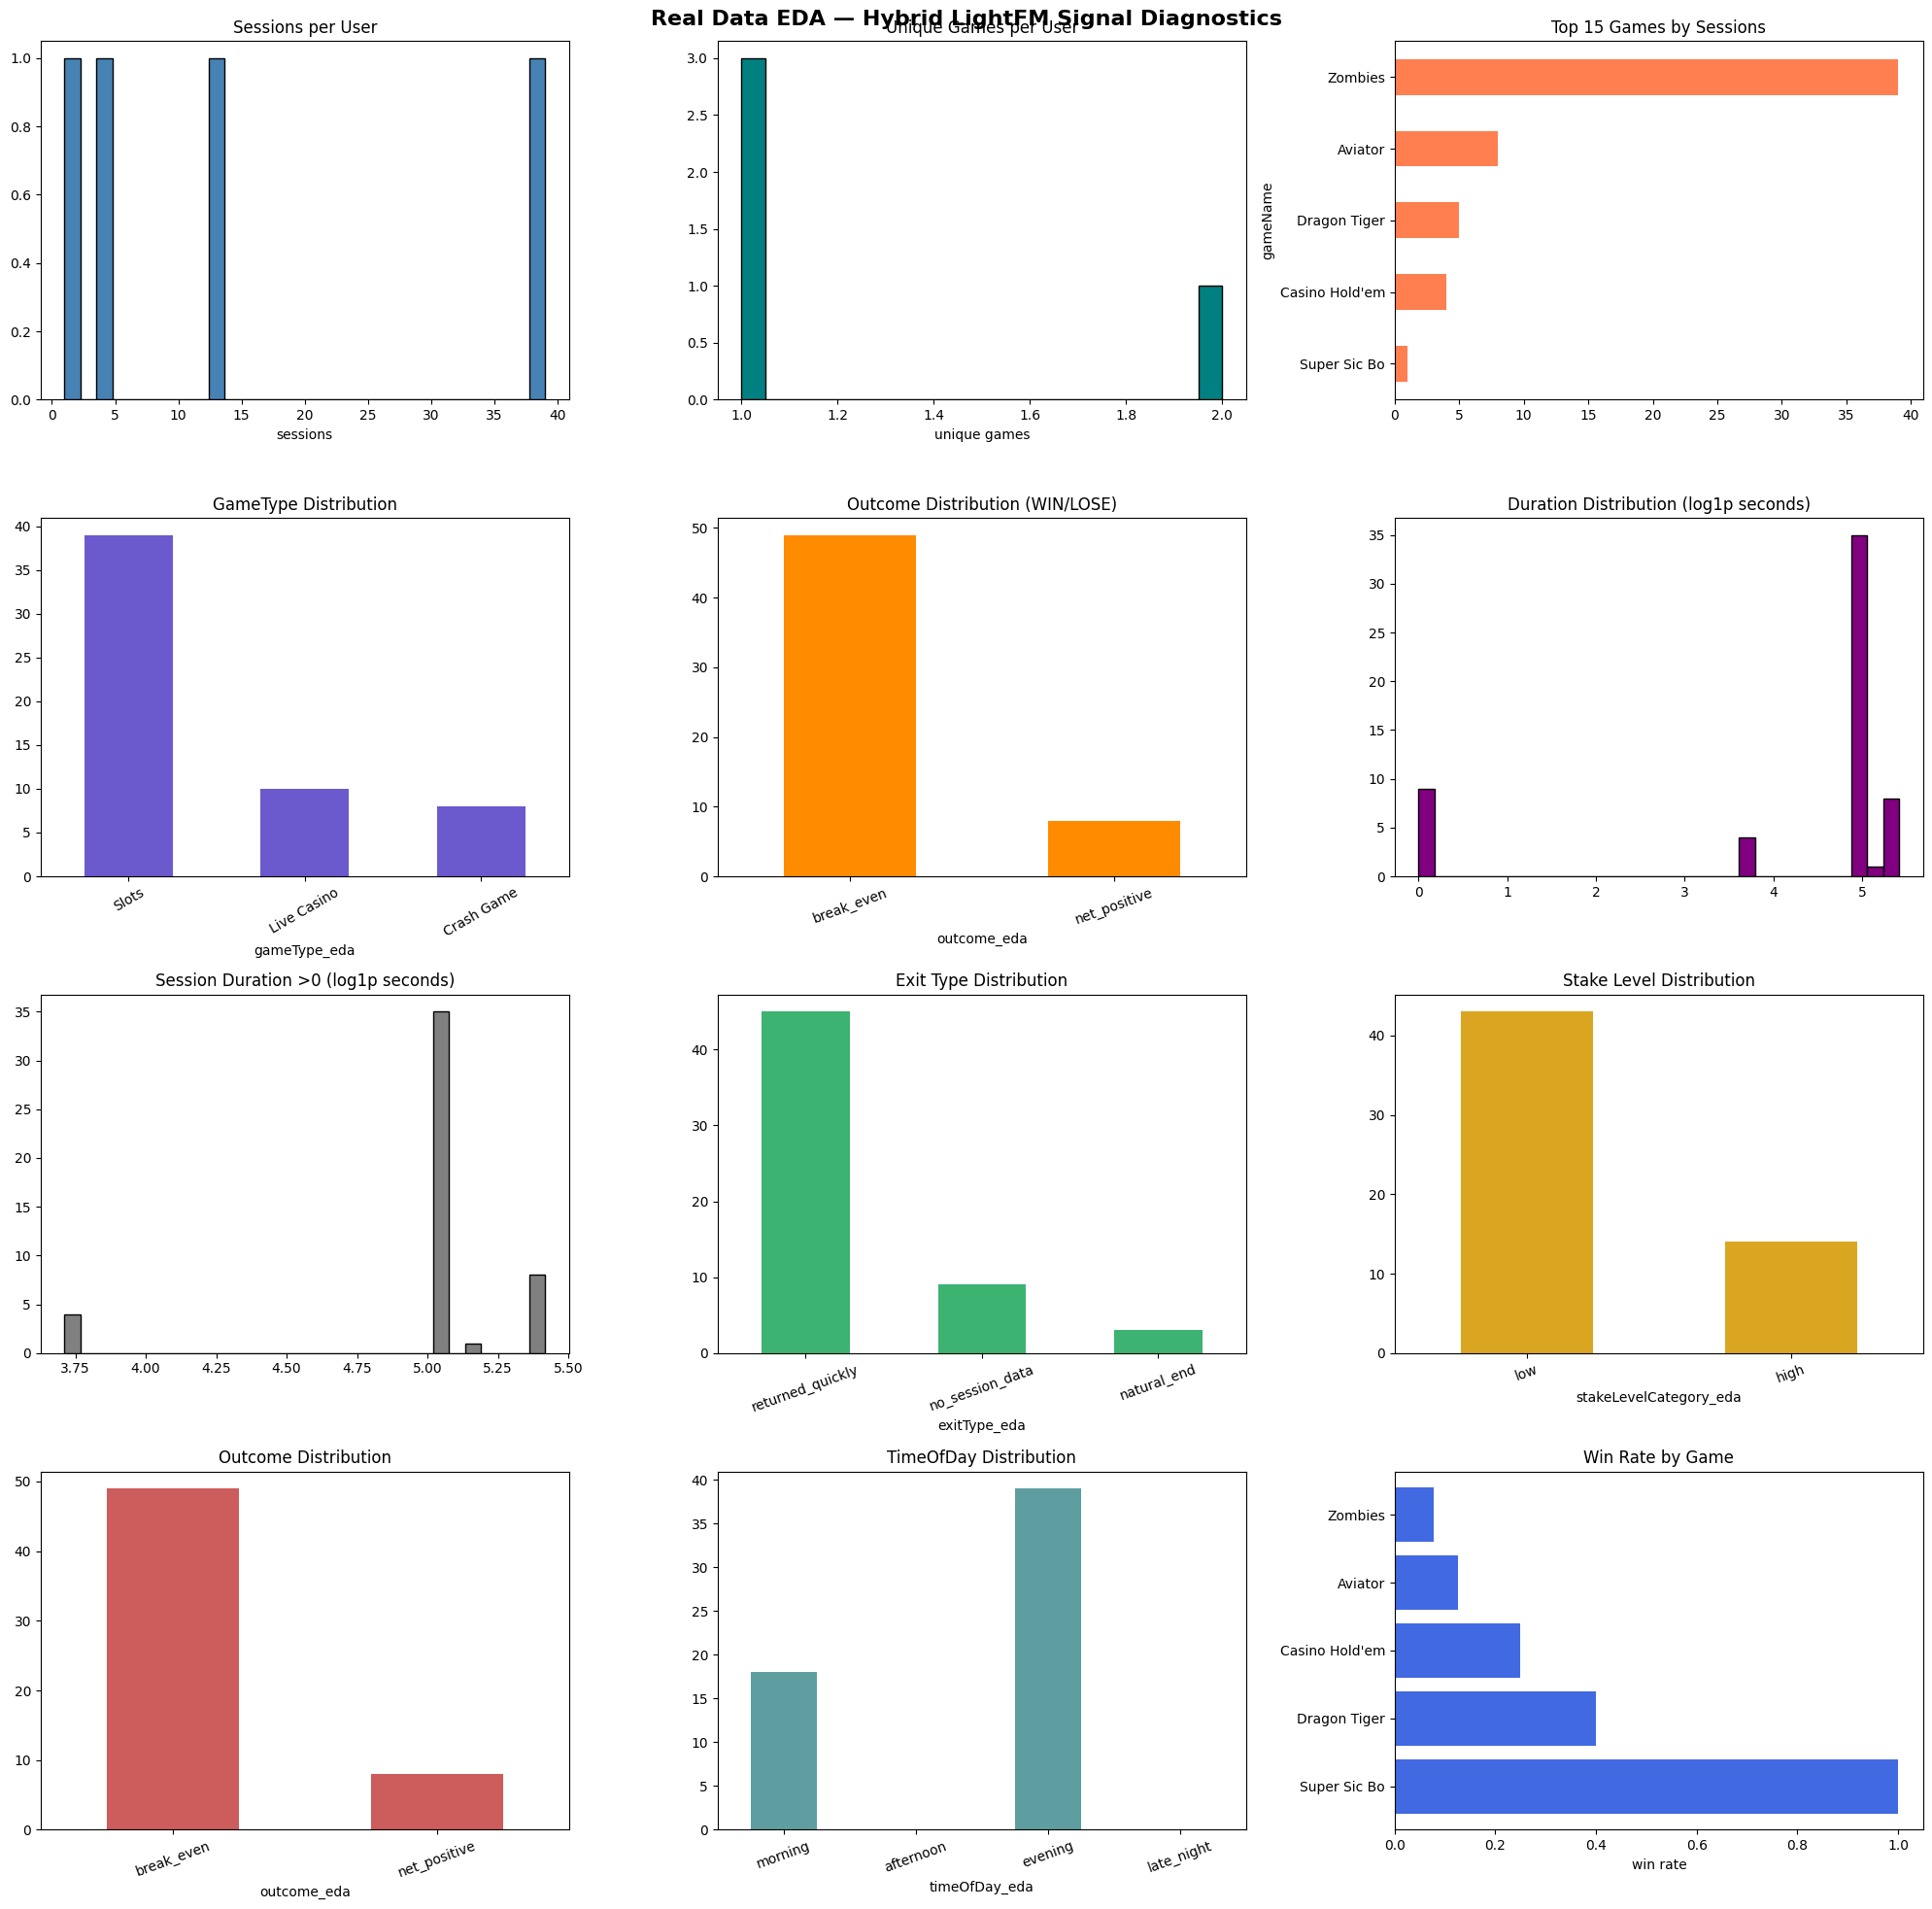

In [19]:
# EDA visualizations for hybrid LightFM signals

fig, axes = plt.subplots(4, 3, figsize=(20, 20))
fig.suptitle('Real Data EDA — Hybrid LightFM Signal Diagnostics', fontsize=16, fontweight='bold')

# 1) User activity: sessions per user
sessions_per_user = eda_df.groupby('userId').size()
axes[0, 0].hist(sessions_per_user, bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Sessions per User')
axes[0, 0].set_xlabel('sessions')

# 2) User activity: games per user
games_per_user = eda_df.groupby('userId')['gameName'].nunique()
axes[0, 1].hist(games_per_user, bins=20, color='teal', edgecolor='black')
axes[0, 1].set_title('Unique Games per User')
axes[0, 1].set_xlabel('unique games')

# 3) Game popularity (top 15)
eda_df['gameName'].value_counts().head(15).sort_values().plot(kind='barh', ax=axes[0, 2], color='coral')
axes[0, 2].set_title('Top 15 Games by Sessions')

# 4) gameType distribution
eda_df['gameType_eda'].value_counts().plot(kind='bar', ax=axes[1, 0], color='slateblue')
axes[1, 0].set_title('GameType Distribution')
axes[1, 0].tick_params(axis='x', rotation=30)

# 5) outcome distribution
eda_df['outcome_eda'].value_counts().plot(kind='bar', ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Outcome Distribution (WIN/LOSE)')
axes[1, 1].tick_params(axis='x', rotation=20)

# 6) engagement: duration
axes[1, 2].hist(np.log1p(eda_df['durationSeconds']), bins=30, color='purple', edgecolor='black')
axes[1, 2].set_title('Duration Distribution (log1p seconds)')

# 7) engagement: session duration (non-zero only)
non_zero_duration = eda_df.loc[eda_df['durationSeconds'] > 0, 'durationSeconds']
axes[2, 0].hist(np.log1p(non_zero_duration), bins=30, color='gray', edgecolor='black')
axes[2, 0].set_title('Session Duration >0 (log1p seconds)')

# 8) engagement: exitType
eda_df['exitType_eda'].value_counts().plot(kind='bar', ax=axes[2, 1], color='mediumseagreen')
axes[2, 1].set_title('Exit Type Distribution')
axes[2, 1].tick_params(axis='x', rotation=20)

# 9) financial signals
eda_df['stakeLevelCategory_eda'].value_counts().plot(kind='bar', ax=axes[2, 2], color='goldenrod')
axes[2, 2].set_title('Stake Level Distribution')
axes[2, 2].tick_params(axis='x', rotation=20)

# 10) outcome
eda_df['outcome_eda'].value_counts().plot(kind='bar', ax=axes[3, 0], color='indianred')
axes[3, 0].set_title('Outcome Distribution')
axes[3, 0].tick_params(axis='x', rotation=20)

# 11) temporal patterns
eda_df['timeOfDay_eda'].value_counts().reindex(['morning','afternoon','evening','late_night'], fill_value=0).plot(kind='bar', ax=axes[3, 1], color='cadetblue')
axes[3, 1].set_title('TimeOfDay Distribution')
axes[3, 1].tick_params(axis='x', rotation=20)

# 12) win rate by game
win_rate_by_game = eda_df.groupby('gameName')['win'].mean().sort_values(ascending=False)
axes[3, 2].barh(win_rate_by_game.index, win_rate_by_game.values, color='royalblue')
axes[3, 2].set_title('Win Rate by Game')
axes[3, 2].set_xlabel('win rate')

plt.tight_layout()
plt.show()

In [20]:
print(eda_df['providerName'].value_counts())

providerName
69afe0e935c654ebc31e4b8f    39
69afe0eb35c654ebc31e4be0    10
69afe0ea35c654ebc31e4ba7     8
Name: count, dtype: int64


### EDA Insights for Hybrid LightFM

- **Sparsity expectation**: sessions/user and games/user distributions indicate long-tail behavior, so user-game matrices will remain sparse.
- **Popularity bias risk**: top games dominate interactions; LightFM should keep metadata features (gameType/provider) to avoid over-recommending only head items.
- **Engagement quality**: `durationSeconds` and `exitType` can differentiate shallow vs high-intent sessions, useful for affinity weighting.
- **Financial segmentation**: `stakeLevelCategory` and `outcome` provide behavioral intensity context for user/game profiling.
- **Temporal/context behavior**: `timeOfDay`, `dayOfWeek`, and source-context fields should be retained as hybrid features when available.

These insights directly motivate the schema-aligned feature engineering in the next sections.

# Hybrid LightFM Recommendation Pipeline (Real Data)

Notebook structure:
1. **Data Loading** (raw ingestion + cleaning)
2. **EDA** (real behavior diagnostics for recommender design)
3. **Schema Alignment** (to TDD `game_session` event schema)
4. **Feature Engineering** (event, user, game, user-game features)
5. **LightFM Dataset Preparation** (model-ready table + sparsity diagnostics)

All logic uses real data only (no simulation, no random volume injection).

In [45]:
# Stage 2A: Utilities for schema alignment

import re

SCHEMA_COLUMNS = [
    'eventType', 'userId', 'sessionId', 'gameId', 'gameType', 'provider', 'timestamp',
    'durationSeconds', 'roundsPlayed', 'stakeLevelCategory', 'outcome',
    'exitType', 'returnedWithin10mins',
    'deviceType', 'timeOfDay', 'dayOfWeek', 'entryPoint'
]

VALID_GAME_TYPES = ['slot', 'table', 'live_dealer', 'crash', 'instant_win', 'unknown']
VALID_PROVIDERS = ['HUB88', 'Evolution', 'EZUGI', 'Spribe', 'OnlyPlay', 'unknown']
VALID_DEVICE_TYPES = ['mobile', 'desktop', 'tablet', 'unknown']
# entryPoint is kept semi-open to preserve real source values (e.g., search, lobby, etc.)
VALID_ENTRY_POINTS = ['livecasino', 'casino', 'sportsbook', 'direct', 'search', 'lobby', 'unknown']
OBJECT_ID_LIKE_RE = re.compile(r'^[0-9a-f]{24}$')


def is_objectid_like(raw_value) -> bool:
    value = str(raw_value).strip().lower()
    return bool(OBJECT_ID_LIKE_RE.fullmatch(value))


def map_game_type(raw_value: str) -> str:
    value = str(raw_value).strip().lower()
    if any(k in value for k in ['live', 'baccarat', 'blackjack', 'roulette', 'sicbo', 'sic bo', 'dragon', 'teen patti', 'andar', 'football studio', 'fan tan', 'bac bo']):
        return 'live_dealer'
    if any(k in value for k in ['slot', 'starburst', 'fruit', 'reel']):
        return 'slot'
    if any(k in value for k in ['table', 'poker']):
        return 'table'
    if any(k in value for k in ['crash', 'aviator', 'cricket crash', 'quantum x', 'cosmox']):
        return 'crash'
    if any(k in value for k in ['instant', 'scratch', 'keno']):
        return 'instant_win'
    return 'unknown'


def map_provider(raw_value: str) -> str:
    value = str(raw_value).strip().lower()
    if value in ('', 'none', 'nan', 'null') or is_objectid_like(value):
        return 'unknown'
    if any(k in value for k in ['evolution', 'evosw', 'evo']):
        return 'Evolution'
    if 'ezugi' in value:
        return 'EZUGI'
    if 'spribe' in value:
        return 'Spribe'
    if 'onlyplay' in value:
        return 'OnlyPlay'
    if 'hub88' in value:
        return 'HUB88'
    # Preserve raw vendor name if not in known set and not an opaque id
    return str(raw_value).strip()


def map_device_type(raw_value: str) -> str:
    value = str(raw_value).strip().lower()
    if any(k in value for k in ['android', 'ios', 'mobile', 'phone']):
        return 'mobile'
    if any(k in value for k in ['desktop', 'web', 'windows', 'mac', 'linux', 'pc']):
        return 'desktop'
    if 'tablet' in value:
        return 'tablet'
    return 'unknown'


def map_entry_point(raw_value: str) -> str:
    value = str(raw_value).strip().lower().replace(' ', '_')
    if value in ('', 'none', 'nan', 'null'):
        return 'unknown'
    if 'live' in value:
        return 'livecasino'
    if 'sport' in value:
        return 'sportsbook'
    if value in ('home', 'direct', 'lobby'):
        return value if value != 'home' else 'direct'
    if 'casino' in value:
        return 'casino'
    # Preserve real source values like search, promo, campaign, etc.
    return value


def map_time_of_day(ts: pd.Series) -> pd.Series:
    hour = ts.dt.hour
    out = np.select(
        [hour.between(6, 11), hour.between(12, 17), hour.between(18, 21)],
        ['morning', 'afternoon', 'evening'],
        default='late_night'
    )
    return pd.Series(out, index=ts.index)


def map_day_of_week(ts: pd.Series) -> pd.Series:
    return ts.dt.day_name().str.lower()


def map_outcome(raw_result: pd.Series) -> pd.Series:
    value = raw_result.astype(str).str.upper()
    return np.where(
        value.eq('WIN'),
        'net_positive',
        np.where(value.eq('LOSS'), 'net_negative', 'break_even')
    )


print('Utilities loaded for schema alignment ✅')

Utilities loaded for schema alignment ✅


## Stage 2 — TDD Schema Alignment

Target event schema:
- eventType, userId, sessionId, gameId, gameType, provider, timestamp
- durationSeconds, roundsPlayed, stakeLevelCategory, outcome
- exitType, returnedWithin10mins
- deviceType, timeOfDay, dayOfWeek, entryPoint

Where raw fields are missing, defaults/assumptions are applied and logged for transparency.

In [46]:
# Stage 2B: Build schema-aligned event dataset


def align_to_event_schema(transactions_df: pd.DataFrame) -> pd.DataFrame:
    df = transactions_df.copy()

    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    if '_id' in df.columns:
        session_id = df['_id'].astype(str).map(lambda x: f'sess_{x}')
    else:
        session_id = pd.Series(range(len(df)), index=df.index).map(lambda x: f'sess_txn_{x}')

    if 'gameId' in df.columns:
        game_id = df['gameId'].astype(str)
    else:
        game_id = 'game_' + df['gameName'].astype(str).str.lower().str.replace(r'[^a-z0-9]+', '_', regex=True).str.strip('_')

    if 'session_duration_sec' in df.columns:
        duration_seconds = pd.to_numeric(df['session_duration_sec'], errors='coerce').fillna(0)
    else:
        duration_seconds = pd.Series(0, index=df.index)

    has_session_data = duration_seconds > 0

    rounds_played = pd.Series(1, index=df.index)

    stake = pd.to_numeric(df['betAmount'], errors='coerce').fillna(0)
    q1, q2 = stake.quantile([0.33, 0.66])
    stake_level = np.select(
        [stake <= q1, stake <= q2],
        ['low', 'medium'],
        default='high'
    )

    entry_raw = df.get('entryPoint_raw', pd.Series(index=df.index, dtype='object')).fillna('unknown')
    device_raw = df.get('deviceType_raw', pd.Series(index=df.index, dtype='object')).fillna('unknown')

    aligned = pd.DataFrame({
        'eventType': 'game_session',
        'userId': df['userId'].astype(str),
        'sessionId': session_id,
        'gameId': game_id,
        'gameType': df.get('categoryName', df.get('gameType', 'unknown')).map(map_game_type),
        'provider': df.get('providerName', 'unknown').map(map_provider),
        'timestamp': df['timestamp'],
        'durationSeconds': duration_seconds.astype(float),
        'roundsPlayed': rounds_played.astype(int),
        'stakeLevelCategory': stake_level,
        'outcome': map_outcome(df.get('result', pd.Series('break_even', index=df.index))),
        'deviceType': device_raw.map(map_device_type),
        'entryPoint': entry_raw.map(map_entry_point),
    })

    # Strong ID sanitization before feature building/training
    aligned['userId'] = aligned['userId'].astype(str).str.strip()
    aligned['gameId'] = aligned['gameId'].astype(str).str.strip()

    invalid_user = aligned['userId'].str.lower().isin({'', 'nan', 'none', 'null'})
    invalid_game = aligned['gameId'].str.lower().isin({'', 'nan', 'none', 'null'})
    invalid_time = aligned['timestamp'].isna()
    drop_mask = invalid_user | invalid_game | invalid_time
    dropped = int(drop_mask.sum())
    if dropped > 0:
        aligned = aligned.loc[~drop_mask].copy()
        print(f'Dropped invalid events: {dropped}')

    aligned = aligned.sort_values(['userId', 'timestamp']).reset_index(drop=True)

    next_ts = aligned.groupby('userId')['timestamp'].shift(-1)
    gap_mins = (next_ts - aligned['timestamp']).dt.total_seconds().div(60)
    aligned['returnedWithin10mins'] = gap_mins.le(10).fillna(False)

    # ExitType: only classify when we have real session duration; otherwise 'unknown'
    aligned['exitType'] = np.select(
        [aligned['durationSeconds'] == 0,
         aligned['durationSeconds'] < 30,
         aligned['returnedWithin10mins']],
        ['unknown', 'quick_exit', 'returned_quickly'],
        default='natural_end'
    )

    aligned['timeOfDay'] = map_time_of_day(aligned['timestamp'])
    aligned['dayOfWeek'] = map_day_of_week(aligned['timestamp'])

    aligned = aligned[SCHEMA_COLUMNS]
    return aligned


events_df = align_to_event_schema(transactions_df)

print(f'Events shape: {events_df.shape}')
print('Schema columns present:', set(SCHEMA_COLUMNS).issubset(events_df.columns))
print('deviceType distribution:')
print(events_df['deviceType'].value_counts(dropna=False))
print('entryPoint distribution:')
print(events_df['entryPoint'].value_counts(dropna=False))
print('exitType distribution:')
print(events_df['exitType'].value_counts(dropna=False))
print('provider distribution:')
print(events_df['provider'].value_counts(dropna=False))
print(events_df.head(3))

Events shape: (57, 17)
Schema columns present: True
deviceType distribution:
deviceType
desktop    57
Name: count, dtype: int64
entryPoint distribution:
entryPoint
livecasino    35
unknown       22
Name: count, dtype: int64
exitType distribution:
exitType
returned_quickly    34
unknown             22
natural_end          1
Name: count, dtype: int64
provider distribution:
provider
unknown    57
Name: count, dtype: int64
      eventType      userId    sessionId   gameId     gameType provider  \
0  game_session  1244444444  sess_txn_44  1571005  live_dealer  unknown   
1  game_session  1244444444  sess_txn_45  1571005  live_dealer  unknown   
2  game_session  1244444444  sess_txn_46  1571005  live_dealer  unknown   

                timestamp  durationSeconds  roundsPlayed stakeLevelCategory  \
0 2026-03-11 07:29:40.421              0.0             1               high   
1 2026-03-11 07:31:18.977              0.0             1               high   
2 2026-03-11 07:31:43.858              

In [ ]:
# Stage 2C: Schema mapping report (source -> schema)

schema_mapping = pd.DataFrame([
    {'schema_field': 'eventType', 'source_field': 'constant', 'mapping': '"game_session"'},
    {'schema_field': 'userId', 'source_field': 'loginId -> userId', 'mapping': 'direct rename'},
    {'schema_field': 'sessionId', 'source_field': '_id (fallback index)', 'mapping': 'sess_<id>'},
    {'schema_field': 'gameId', 'source_field': 'gameId (fallback gameName slug)', 'mapping': 'string cast / slug'},
    {'schema_field': 'gameType', 'source_field': 'categoryName / gameType', 'mapping': 'normalized into TDD enums'},
    {'schema_field': 'provider', 'source_field': 'gamedetails.gamevendor', 'mapping': 'mapped to Evolution/EZUGI/Spribe/etc. or unknown for opaque ids'},
    {'schema_field': 'timestamp', 'source_field': 'createdDate -> timestamp', 'mapping': 'datetime cast'},
    {'schema_field': 'durationSeconds', 'source_field': 'usersessionlog join', 'mapping': 'livecasino session_duration_sec else 0'},
    {'schema_field': 'roundsPlayed', 'source_field': 'proxy', 'mapping': '1 per settled event'},
    {'schema_field': 'stakeLevelCategory', 'source_field': 'betAmount', 'mapping': 'quantile buckets low/medium/high'},
    {'schema_field': 'outcome', 'source_field': 'result', 'mapping': 'WIN/LOSS/other -> net_positive/net_negative/break_even'},
    {'schema_field': 'exitType', 'source_field': 'durationSeconds + return gap', 'mapping': 'unknown (no session) / quick_exit / returned_quickly / natural_end'},
    {'schema_field': 'returnedWithin10mins', 'source_field': 'next user event gap', 'mapping': '<=10 mins boolean'},
    {'schema_field': 'deviceType', 'source_field': 'useractivitylogs.device_type', 'mapping': 'prioritized joins: userId->playerId, player bridge, then login/user ids'},
    {'schema_field': 'timeOfDay', 'source_field': 'timestamp hour', 'mapping': 'bucketed to late_night/morning/afternoon/evening'},
    {'schema_field': 'dayOfWeek', 'source_field': 'timestamp', 'mapping': 'lowercase weekday'},
    {'schema_field': 'entryPoint', 'source_field': 'usersessionlog.source', 'mapping': 'mapped to livecasino/casino/sportsbook/direct/unknown'},
])

print('Schema mapping table:')
display(schema_mapping)

Schema mapping table:


,schema_field,source_field,mapping
0,eventType,constant,"""game_session"""
1,userId,loginId -> userId,direct rename
2,sessionId,_id (fallback index),sess_<id>
3,gameId,gameId (fallback gameName slug),string cast / slug
4,gameType,categoryName / gameType,normalized into TDD enums
5,provider,gamedetails.gamevendor,mapped to Evolution/EZUGI/Spribe/etc.
6,timestamp,createdDate -> timestamp,datetime cast
7,durationSeconds,usersessionlog join,session_duration_sec else 0
8,roundsPlayed,proxy,1 per settled event
9,stakeLevelCategory,betAmount,quantile buckets low/medium/high


In [47]:
# Stage 3A: Event-level feature engineering

fe_events = events_df.copy()

# Session behavior features
fe_events['is_quick_exit'] = (fe_events['exitType'] == 'quick_exit').astype(int)
fe_events['is_positive_outcome'] = (fe_events['outcome'] == 'net_positive').astype(int)
fe_events['is_negative_outcome'] = (fe_events['outcome'] == 'net_negative').astype(int)

# Engagement intensity proxy
stake_weight = fe_events['stakeLevelCategory'].map({'low': 1, 'medium': 2, 'high': 3}).fillna(1)
fe_events['engagement_intensity'] = (
    np.log1p(fe_events['durationSeconds'].clip(lower=0)) * 0.5
    + fe_events['roundsPlayed'].clip(lower=0) * 0.3
    + stake_weight * 0.2
)

# User recency features
fe_events = fe_events.sort_values(['userId', 'timestamp']).reset_index(drop=True)
prev_ts = fe_events.groupby('userId')['timestamp'].shift(1)
fe_events['minutes_since_prev_event'] = (fe_events['timestamp'] - prev_ts).dt.total_seconds().div(60)
fe_events['minutes_since_prev_event'] = fe_events['minutes_since_prev_event'].fillna(1e6)

print('Event-level features created ✅')
print(fe_events[['engagement_intensity', 'is_quick_exit', 'is_positive_outcome', 'minutes_since_prev_event']].describe().round(3))

Event-level features created ✅
       engagement_intensity  is_quick_exit  is_positive_outcome  \
count                57.000           57.0                57.00   
mean                  2.145            0.0                 0.14   
std                   1.119            0.0                 0.35   
min                   0.500            0.0                 0.00   
25%                   0.900            0.0                 0.00   
50%                   3.019            0.0                 0.00   
75%                   3.019            0.0                 0.00   
max                   3.019            0.0                 1.00   

       minutes_since_prev_event  
count                    57.000  
mean                  70175.712  
std                  257713.021  
min                       0.055  
25%                       0.057  
50%                       0.110  
75%                       0.415  
max                 1000000.000  


In [48]:
# Stage 3B: User-level features (schema-driven)

user_features_df = fe_events.groupby('userId').agg(
    total_sessions=('sessionId', 'count'),
    unique_games=('gameId', 'nunique'),
    unique_providers=('provider', 'nunique'),
    unique_game_types=('gameType', 'nunique'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    quick_exit_rate=('is_quick_exit', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
    avg_engagement_intensity=('engagement_intensity', 'mean'),
    preferred_time_of_day=('timeOfDay', lambda x: x.mode().iat[0] if len(x.mode()) else 'late_night'),
    preferred_day_of_week=('dayOfWeek', lambda x: x.mode().iat[0] if len(x.mode()) else 'friday'),
    preferred_device=('deviceType', lambda x: x.mode().iat[0] if len(x.mode()) else 'mobile'),
    preferred_entry_point=('entryPoint', lambda x: x.mode().iat[0] if len(x.mode()) else 'direct'),
    last_event_ts=('timestamp', 'max'),
).reset_index()

max_ts = fe_events['timestamp'].max()
user_features_df['recency_days'] = (max_ts - user_features_df['last_event_ts']).dt.total_seconds().div(86400)

print(f'User features shape: {user_features_df.shape}')
user_features_df.head(3)

User features shape: (4, 17)


,userId,total_sessions,unique_games,unique_providers,unique_game_types,avg_duration_sec,avg_rounds,quick_exit_rate,return_10m_rate,positive_outcome_rate,avg_engagement_intensity,preferred_time_of_day,preferred_day_of_week,preferred_device,preferred_entry_point,last_event_ts,recency_days
0,1244444444,13,2,1,2,0.000000,1.0,0.0,0.923077,0.230769,0.900000,morning,wednesday,desktop,unknown,2026-03-11 07:35:24.214,0.000000
1,3355335533,1,1,1,1,0.000000,1.0,0.0,0.000000,1.000000,0.500000,morning,wednesday,desktop,unknown,2026-03-11 06:42:25.129,0.036795
2,5097103780,39,1,1,1,137.590385,1.0,0.0,0.974359,0.076923,2.761088,evening,tuesday,desktop,livecasino,2026-03-10 18:16:42.548,0.554649


## Stage 3 — Schema-Driven Feature Engineering

Features are built from aligned event fields:
- Session behavior (duration, rounds proxy, exit behavior)
- Engagement signals (return behavior, quick exits)
- Preference signals (game, gameType, provider)
- Temporal patterns (timeOfDay, dayOfWeek)
- Device/context patterns (deviceType, entryPoint)
- Recency-frequency and user-game affinity signals

In [49]:
# Stage 3C: Game and provider features

game_features_df = fe_events.groupby('gameId').agg(
    game_sessions=('sessionId', 'count'),
    unique_users=('userId', 'nunique'),
    game_type=('gameType', lambda x: x.mode().iat[0] if len(x.mode()) else 'live_dealer'),
    provider=('provider', lambda x: x.mode().iat[0] if len(x.mode()) else 'HUB88'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    quick_exit_rate=('is_quick_exit', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
).reset_index()

game_features_df['popularity_score'] = np.log1p(game_features_df['game_sessions'])

provider_features_df = fe_events.groupby('provider').agg(
    provider_sessions=('sessionId', 'count'),
    provider_unique_users=('userId', 'nunique'),
    provider_avg_engagement=('engagement_intensity', 'mean'),
).reset_index()

print(f'Game features shape: {game_features_df.shape}')
print(f'Provider features shape: {provider_features_df.shape}')
game_features_df.head(3)

Game features shape: (5, 11)
Provider features shape: (1, 4)


,gameId,game_sessions,unique_users,game_type,provider,avg_duration_sec,avg_rounds,quick_exit_rate,return_10m_rate,positive_outcome_rate,popularity_score
0,1476410,4,1,live_dealer,unknown,0.0,1.0,0.0,0.75,0.25,1.609438
1,1571005,5,1,live_dealer,unknown,0.0,1.0,0.0,1.00,0.40,1.791759
2,1571026,1,1,live_dealer,unknown,0.0,1.0,0.0,0.00,1.00,0.693147


In [50]:
# Stage 4: User-game affinity + interaction features

user_game_df = fe_events.groupby(['userId', 'gameId']).agg(
    interaction_count=('sessionId', 'count'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    avg_engagement_intensity=('engagement_intensity', 'mean'),
    last_interaction_ts=('timestamp', 'max'),
    dominant_game_type=('gameType', lambda x: x.mode().iat[0] if len(x.mode()) else 'live_dealer'),
    dominant_provider=('provider', lambda x: x.mode().iat[0] if len(x.mode()) else 'HUB88'),
).reset_index()

max_ts = fe_events['timestamp'].max()
user_game_df['recency_days'] = (max_ts - user_game_df['last_interaction_ts']).dt.total_seconds().div(86400)

# Implicit score inspired by recsys.ipynb pattern (frequency + quality + recency)
freq_score = np.minimum(user_game_df['interaction_count'] / 20.0, 1.0)
engagement_score = np.minimum(user_game_df['avg_engagement_intensity'] / np.maximum(user_game_df['avg_engagement_intensity'].quantile(0.95), 1e-6), 1.0)
quality_score = user_game_df['positive_outcome_rate'].fillna(0)
recency_weight = np.where(
    user_game_df['recency_days'] <= 7, 1.0,
    np.where(user_game_df['recency_days'] <= 30, 0.7, np.where(user_game_df['recency_days'] <= 90, 0.4, 0.2))
)

user_game_df['implicit_score'] = (
    0.40 * freq_score
    + 0.25 * engagement_score
    + 0.15 * quality_score
    + 0.20 * recency_weight
).round(4)

print(f'User-game interactions: {user_game_df.shape}')
print(user_game_df['implicit_score'].describe().round(3))

User-game interactions: (5, 13)
count    5.000
mean     0.518
std      0.195
min      0.380
25%      0.422
50%      0.454
75%      0.473
max      0.862
Name: implicit_score, dtype: float64


In [51]:
# Stage 5: LightFM dataset preparation (model-ready table)

model_ready_df = (
    user_game_df
    .merge(user_features_df.drop(columns=['last_event_ts']), on='userId', how='left')
    .merge(game_features_df, on='gameId', how='left', suffixes=('_ug', '_g'))
)

# Clean NA values for model readiness
numeric_cols = model_ready_df.select_dtypes(include=[np.number]).columns
categorical_cols = model_ready_df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns

model_ready_df[numeric_cols] = model_ready_df[numeric_cols].fillna(0)
model_ready_df[categorical_cols] = model_ready_df[categorical_cols].fillna('unknown')

print(f'Model-ready dataset shape: {model_ready_df.shape}')
print('Sample columns:', model_ready_df.columns[:20].tolist())
model_ready_df.head(3)

Model-ready dataset shape: (5, 38)
Sample columns: ['userId', 'gameId', 'interaction_count', 'avg_duration_sec_x', 'avg_rounds_x', 'positive_outcome_rate_x', 'return_10m_rate_x', 'avg_engagement_intensity_x', 'last_interaction_ts', 'dominant_game_type', 'dominant_provider', 'recency_days_x', 'implicit_score', 'total_sessions', 'unique_games', 'unique_providers', 'unique_game_types', 'avg_duration_sec_y', 'avg_rounds_y', 'quick_exit_rate_ug']


,userId,gameId,interaction_count,avg_duration_sec_x,avg_rounds_x,positive_outcome_rate_x,return_10m_rate_x,avg_engagement_intensity_x,last_interaction_ts,dominant_game_type,...,game_sessions,unique_users,game_type,provider,avg_duration_sec,avg_rounds,quick_exit_rate_g,return_10m_rate,positive_outcome_rate,popularity_score
0,1244444444,1571005,5,0.0,1.0,0.400,1.000,0.9,2026-03-11 07:32:33.917,live_dealer,...,5,1,live_dealer,unknown,0.0,1.0,0.0,1.000,0.400,1.791759
1,1244444444,2162016,8,0.0,1.0,0.125,0.875,0.9,2026-03-11 07:35:24.214,crash,...,8,1,crash,unknown,0.0,1.0,0.0,0.875,0.125,2.197225
2,3355335533,1571026,1,0.0,1.0,1.000,0.000,0.5,2026-03-11 06:42:25.129,live_dealer,...,1,1,live_dealer,unknown,0.0,1.0,0.0,0.000,1.000,0.693147


=== Recommendation Data Geometry ===
Events:               57
Users:                4
Games:                5
User-game pairs:      5
Interaction density:  25.0000%


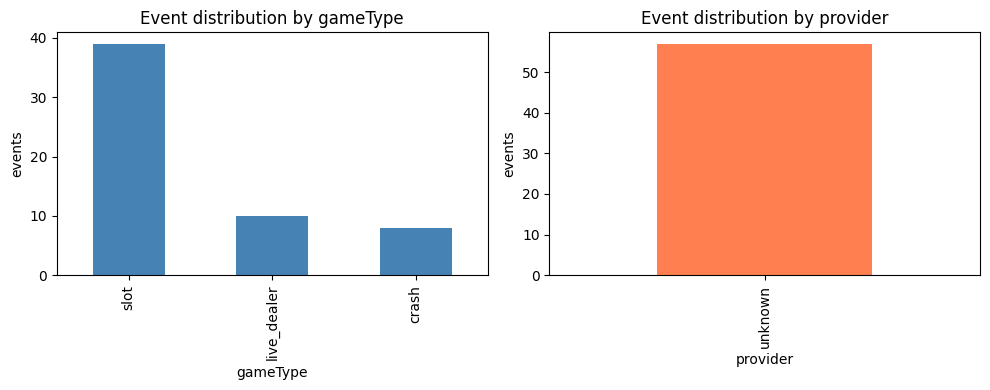

In [52]:
# Stage 5B: Lightweight diagnostics for coverage and sparsity

n_users = events_df['userId'].nunique()
n_games = events_df['gameId'].nunique()
n_pairs = user_game_df.groupby(['userId', 'gameId']).ngroups
density = n_pairs / max(n_users * n_games, 1)

print('=== Recommendation Data Geometry ===')
print(f'Events:               {len(events_df):,}')
print(f'Users:                {n_users:,}')
print(f'Games:                {n_games:,}')
print(f'User-game pairs:      {n_pairs:,}')
print(f'Interaction density:  {density * 100:.4f}%')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
events_df['gameType'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Event distribution by gameType')
plt.xlabel('gameType')
plt.ylabel('events')

plt.subplot(1, 2, 2)
events_df['provider'].value_counts().plot(kind='bar', color='coral')
plt.title('Event distribution by provider')
plt.xlabel('provider')
plt.ylabel('events')

plt.tight_layout()
plt.show()

## Stage 6 — Hybrid LightFM Model Training

This section trains LightFM on schema-aligned real-data interactions with user/item metadata features.

In [54]:
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import precision_at_k, auc_score
from scipy.sparse import csr_matrix

SEED = 42


def _mode_or_default(series, default_value):
    mode = series.mode()
    return mode.iat[0] if len(mode) else default_value


def build_feature_tables_from_events(base_events: pd.DataFrame):
    fe_local = base_events.copy().sort_values(['userId', 'timestamp']).reset_index(drop=True)

    fe_local['is_quick_exit'] = (fe_local['exitType'] == 'quick_exit').astype(int)
    fe_local['is_positive_outcome'] = (fe_local['outcome'] == 'net_positive').astype(int)
    fe_local['is_negative_outcome'] = (fe_local['outcome'] == 'net_negative').astype(int)

    stake_weight_local = fe_local['stakeLevelCategory'].map({'low': 1, 'medium': 2, 'high': 3}).fillna(1)
    fe_local['engagement_intensity'] = (
        np.log1p(fe_local['durationSeconds'].clip(lower=0)) * 0.5
        + fe_local['roundsPlayed'].clip(lower=0) * 0.3
        + stake_weight_local * 0.2
    )

    prev_ts_local = fe_local.groupby('userId')['timestamp'].shift(1)
    fe_local['minutes_since_prev_event'] = (
        fe_local['timestamp'] - prev_ts_local
    ).dt.total_seconds().div(60).fillna(1e6)

    user_features_local = fe_local.groupby('userId').agg(
        total_sessions=('sessionId', 'count'),
        unique_games=('gameId', 'nunique'),
        unique_providers=('provider', 'nunique'),
        unique_game_types=('gameType', 'nunique'),
        avg_duration_sec=('durationSeconds', 'mean'),
        avg_rounds=('roundsPlayed', 'mean'),
        quick_exit_rate=('is_quick_exit', 'mean'),
        return_10m_rate=('returnedWithin10mins', 'mean'),
        positive_outcome_rate=('is_positive_outcome', 'mean'),
        avg_engagement_intensity=('engagement_intensity', 'mean'),
        preferred_time_of_day=('timeOfDay', lambda x: _mode_or_default(x, 'late_night')),
        preferred_day_of_week=('dayOfWeek', lambda x: _mode_or_default(x, 'friday')),
        preferred_device=('deviceType', lambda x: _mode_or_default(x, 'unknown')),
        preferred_entry_point=('entryPoint', lambda x: _mode_or_default(x, 'unknown')),
        last_event_ts=('timestamp', 'max'),
    ).reset_index()

    max_ts_local = fe_local['timestamp'].max()
    user_features_local['recency_days'] = (
        max_ts_local - user_features_local['last_event_ts']
    ).dt.total_seconds().div(86400)

    game_features_local = fe_local.groupby('gameId').agg(
        game_sessions=('sessionId', 'count'),
        unique_users=('userId', 'nunique'),
        game_type=('gameType', lambda x: _mode_or_default(x, 'live_dealer')),
        provider=('provider', lambda x: _mode_or_default(x, 'unknown')),
        avg_duration_sec=('durationSeconds', 'mean'),
        avg_rounds=('roundsPlayed', 'mean'),
        quick_exit_rate=('is_quick_exit', 'mean'),
        return_10m_rate=('returnedWithin10mins', 'mean'),
        positive_outcome_rate=('is_positive_outcome', 'mean'),
    ).reset_index()
    game_features_local['popularity_score'] = np.log1p(game_features_local['game_sessions'])

    provider_features_local = fe_local.groupby('provider').agg(
        provider_sessions=('sessionId', 'count'),
        provider_unique_users=('userId', 'nunique'),
        provider_avg_engagement=('engagement_intensity', 'mean'),
    ).reset_index()

    user_game_local = fe_local.groupby(['userId', 'gameId']).agg(
        interaction_count=('sessionId', 'count'),
        avg_duration_sec=('durationSeconds', 'mean'),
        avg_rounds=('roundsPlayed', 'mean'),
        positive_outcome_rate=('is_positive_outcome', 'mean'),
        return_10m_rate=('returnedWithin10mins', 'mean'),
        avg_engagement_intensity=('engagement_intensity', 'mean'),
        last_interaction_ts=('timestamp', 'max'),
        dominant_game_type=('gameType', lambda x: _mode_or_default(x, 'live_dealer')),
        dominant_provider=('provider', lambda x: _mode_or_default(x, 'unknown')),
    ).reset_index()

    user_game_local['recency_days'] = (
        max_ts_local - user_game_local['last_interaction_ts']
    ).dt.total_seconds().div(86400)

    freq_score_local = np.minimum(user_game_local['interaction_count'] / 20.0, 1.0)
    engagement_denom = max(user_game_local['avg_engagement_intensity'].quantile(0.95), 1e-6)
    engagement_score_local = np.minimum(
        user_game_local['avg_engagement_intensity'] / engagement_denom,
        1.0
    )
    quality_score_local = user_game_local['positive_outcome_rate'].fillna(0)
    recency_weight_local = np.where(
        user_game_local['recency_days'] <= 7, 1.0,
        np.where(
            user_game_local['recency_days'] <= 30, 0.7,
            np.where(user_game_local['recency_days'] <= 90, 0.4, 0.2)
        )
    )

    user_game_local['implicit_score'] = (
        0.40 * freq_score_local
        + 0.25 * engagement_score_local
        + 0.15 * quality_score_local
        + 0.20 * recency_weight_local
    ).round(4)

    return fe_local, user_features_local, game_features_local, provider_features_local, user_game_local


def assign_popularity_bucket(score_series: pd.Series) -> pd.Series:
    n_rows = len(score_series)
    if n_rows == 0:
        return pd.Series(dtype='object')
    labels = ['cold', 'warm', 'hot', 'blockbuster'][:min(4, n_rows)]
    if len(labels) == 1:
        return pd.Series([labels[0]] * n_rows, index=score_series.index, dtype='object')
    ranked = score_series.rank(method='first')
    try:
        return pd.qcut(ranked, q=len(labels), labels=labels, duplicates='drop').astype(str)
    except ValueError:
        return pd.Series([labels[0]] * n_rows, index=score_series.index, dtype='object')


events_for_split = events_df.sort_values(['userId', 'timestamp']).copy()
pair_last_touch = (
    events_for_split.groupby(['userId', 'gameId'], as_index=False)
    .agg(last_ts=('timestamp', 'max'))
)
pair_last_touch['distinct_games_for_user'] = pair_last_touch.groupby('userId')['gameId'].transform('nunique')

holdout_pairs_df = (
    pair_last_touch[pair_last_touch['distinct_games_for_user'] >= 2]
    .sort_values(['userId', 'last_ts'])
    .groupby('userId', as_index=False)
    .tail(1)[['userId', 'gameId']]
)

if len(holdout_pairs_df) == 0:
    raise ValueError('No holdout user-game pairs available for evaluation. Dataset is too small or too dense.')

holdout_keys = {tuple(x) for x in holdout_pairs_df[['userId', 'gameId']].to_records(index=False)}
pair_keys = list(zip(events_for_split['userId'], events_for_split['gameId']))
holdout_mask = pd.Series([key in holdout_keys for key in pair_keys], index=events_for_split.index)

train_events_df = events_for_split.loc[~holdout_mask].copy()
test_events_raw_df = events_for_split.loc[holdout_mask].copy()

(
    train_fe_events,
    train_user_features_df,
    train_game_features_df,
    train_provider_features_df,
    train_user_game_df,
) = build_feature_tables_from_events(train_events_df)

test_user_game_df = (
    test_events_raw_df.groupby(['userId', 'gameId']).size()
    .reset_index(name='interaction_count')
)
test_user_game_df['implicit_score'] = 1.0

safe_train_user_game_df = train_user_game_df.copy()
safe_train_user_game_df['userId'] = safe_train_user_game_df['userId'].astype(str).str.strip()
safe_train_user_game_df['gameId'] = safe_train_user_game_df['gameId'].astype(str).str.strip()
valid_mask = (
    ~safe_train_user_game_df['userId'].str.lower().isin(['', 'nan', 'none', 'null'])
    & ~safe_train_user_game_df['gameId'].str.lower().isin(['', 'nan', 'none', 'null'])
)
safe_train_user_game_df = safe_train_user_game_df[valid_mask].copy()

test_user_game_df['userId'] = test_user_game_df['userId'].astype(str).str.strip()
test_user_game_df['gameId'] = test_user_game_df['gameId'].astype(str).str.strip()

active_users = np.union1d(
    safe_train_user_game_df['userId'].unique(),
    test_user_game_df['userId'].unique()
)
active_items = np.union1d(
    safe_train_user_game_df['gameId'].unique(),
    test_user_game_df['gameId'].unique()
)

ufe = train_user_features_df[train_user_features_df['userId'].astype(str).isin(active_users)].copy()

static_item_meta = events_df.groupby('gameId').agg(
    game_type_static=('gameType', lambda x: _mode_or_default(x, 'unknown')),
    provider_static=('provider', lambda x: _mode_or_default(x, 'unknown')),
).reset_index()

ife = pd.DataFrame({'gameId': active_items})
ife = ife.merge(train_game_features_df, on='gameId', how='left')
ife = ife.merge(static_item_meta, on='gameId', how='left')
ife['game_type'] = ife['game_type'].fillna(ife['game_type_static']).fillna('unknown')
ife['provider'] = ife['provider'].fillna(ife['provider_static']).fillna('unknown')
for numeric_col in ['game_sessions', 'unique_users', 'avg_duration_sec', 'avg_rounds', 'quick_exit_rate', 'return_10m_rate', 'positive_outcome_rate', 'popularity_score']:
    if numeric_col in ife.columns:
        ife[numeric_col] = ife[numeric_col].fillna(0)
ife['popularity_bucket'] = assign_popularity_bucket(ife['popularity_score'])

def user_tokens(row):
    return [
        f"preferred_time_of_day:{row['preferred_time_of_day']}",
        f"preferred_day_of_week:{row['preferred_day_of_week']}",
        f"preferred_device:{row['preferred_device']}",
        f"preferred_entry_point:{row['preferred_entry_point']}",
    ]

def item_tokens(row):
    return [
        f"game_type:{row['game_type']}",
        f"provider:{row['provider']}",
        f"popularity_bucket:{row['popularity_bucket']}",
    ]

user_feature_vocab = sorted({tok for _, r in ufe.iterrows() for tok in user_tokens(r)})
item_feature_vocab = sorted({tok for _, r in ife.iterrows() for tok in item_tokens(r)})

dataset = Dataset()
dataset.fit(
    users=active_users,
    items=active_items,
    user_features=user_feature_vocab,
    item_features=item_feature_vocab,
)

full_eval_pairs_df = pd.concat([
    safe_train_user_game_df[['userId', 'gameId', 'implicit_score']],
    test_user_game_df[['userId', 'gameId', 'implicit_score']],
], ignore_index=True).drop_duplicates(['userId', 'gameId'], keep='first')

(interactions, _) = dataset.build_interactions(
    (str(r['userId']), str(r['gameId']), float(r['implicit_score']))
    for _, r in full_eval_pairs_df.iterrows()
)
(train_interactions, train_weights) = dataset.build_interactions(
    (str(r['userId']), str(r['gameId']), float(r['implicit_score']))
    for _, r in safe_train_user_game_df.iterrows()
)
(test_interactions, _) = dataset.build_interactions(
    (str(r['userId']), str(r['gameId']), 1.0)
    for _, r in test_user_game_df.iterrows()
)

weights = train_weights
user_features_matrix = dataset.build_user_features(
    (str(r['userId']), user_tokens(r)) for _, r in ufe.iterrows()
)
item_features_matrix = dataset.build_item_features(
    (str(r['gameId']), item_tokens(r)) for _, r in ife.iterrows()
)

n_users_built = len(active_users)
n_items_built = len(active_items)
n_pairs_built = len(safe_train_user_game_df)

print('LightFM artifacts built ✅')
print(f'Leakage-safe holdout pairs: {len(test_user_game_df)}')
print('Interactions:', interactions.shape, '| nnz =', interactions.nnz)
print('Train nnz:', train_interactions.nnz, '| Test nnz:', test_interactions.nnz)
print('User feature matrix:', user_features_matrix.shape)
print('Item feature matrix:', item_features_matrix.shape)
print(f'User feature tokens: {user_feature_vocab}')
print(f'Item feature tokens: {item_feature_vocab}')

LightFM artifacts built ✅
Leakage-safe holdout pairs: 1
Interactions: (4, 5) | nnz = 5
Train nnz: 4 | Test nnz: 1
User feature matrix: (4, 11)
Item feature matrix: (5, 13)
User feature tokens: ['preferred_day_of_week:tuesday', 'preferred_day_of_week:wednesday', 'preferred_device:desktop', 'preferred_entry_point:livecasino', 'preferred_entry_point:unknown', 'preferred_time_of_day:evening', 'preferred_time_of_day:morning']
Item feature tokens: ['game_type:crash', 'game_type:live_dealer', 'game_type:slot', 'popularity_bucket:blockbuster', 'popularity_bucket:cold', 'popularity_bucket:hot', 'popularity_bucket:warm', 'provider:unknown']


In [55]:
# Train LightFM

model = LightFM(
    no_components=32,
    loss='warp',
    learning_rate=0.03,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=SEED,
)

N_EPOCHS = 20
train_hist, test_hist = [], []

for epoch in range(N_EPOCHS):
    model.fit_partial(
        interactions=train_interactions,
        sample_weight=train_weights,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
        epochs=1,
    )

    if (epoch + 1) % 5 == 0:
        tr_p = precision_at_k(
            model, train_interactions,
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            k=5, num_threads=4,
        ).mean()
        te_p = precision_at_k(
            model, test_interactions,
            train_interactions=train_interactions,
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            k=5, num_threads=4,
        ).mean()
        train_hist.append(float(tr_p))
        test_hist.append(float(te_p))
        print(f'Epoch {epoch+1:2d}/{N_EPOCHS} | Train P@5: {tr_p:.4f} | Test P@5: {te_p:.4f}')

print('Training complete ✅')

Epoch  5/20 | Train P@5: 0.2000 | Test P@5: 0.2000
Epoch 10/20 | Train P@5: 0.2000 | Test P@5: 0.2000
Epoch 15/20 | Train P@5: 0.2000 | Test P@5: 0.2000
Epoch 20/20 | Train P@5: 0.2000 | Test P@5: 0.2000
Training complete ✅


## Stage 7 — Evaluation & Recommendation Preview

Primary metrics:
- Precision@5
- AUC
- Learning trend across checkpoints

Also includes sample top-N recommendations for a real user.

LightFM Evaluation Summary
Train Precision@5: 0.2000
Test  Precision@5: 0.2000
Train AUC:         0.6250
Test  AUC:         0.0000
NDCG@5:            0.4307
Generalization gap: 0.0000


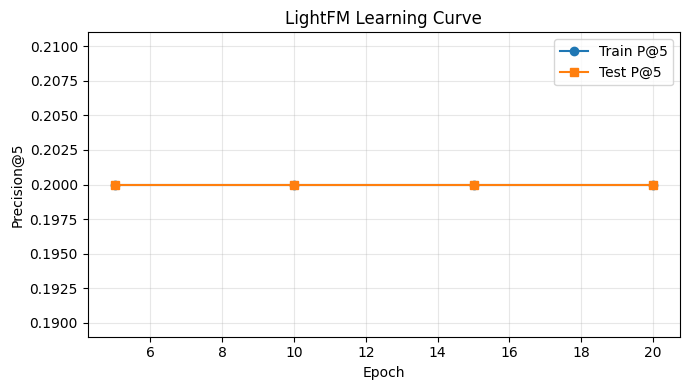


Sample recommendations for user: 1244444444


,gameId,score
0,2970554,-0.075871
1,1571026,-0.161882
2,1476410,-0.164850


In [56]:
# Evaluation metrics + sample recommendations

from sklearn.metrics import ndcg_score

final_train_p5 = precision_at_k(
    model, train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5, num_threads=4,
).mean()

final_test_p5 = precision_at_k(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5, num_threads=4,
).mean()

final_train_auc = auc_score(
    model, train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    num_threads=4,
).mean()

final_test_auc = auc_score(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    num_threads=4,
).mean()

# NDCG@5 on users with test interactions (excluding known train items)
n_users_eval, n_items_eval = test_interactions.shape
test_csr_eval = csr_matrix(test_interactions)
train_csr_eval = csr_matrix(train_interactions)
ndcg_vals = []
for user_idx in range(n_users_eval):
    true_items = test_csr_eval.getrow(user_idx).indices
    if len(true_items) == 0:
        continue
    scores = model.predict(
        user_ids=np.repeat(user_idx, n_items_eval),
        item_ids=np.arange(n_items_eval),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )

    known_train = train_csr_eval.getrow(user_idx).indices
    scores_ndcg = scores.copy()
    if len(known_train) > 0:
        scores_ndcg[known_train] = -1e9

    y_true = np.zeros(n_items_eval)
    y_true[true_items] = 1
    ndcg_vals.append(ndcg_score([y_true], [scores_ndcg], k=5))

final_ndcg5 = float(np.mean(ndcg_vals)) if len(ndcg_vals) > 0 else float('nan')

print('=' * 52)
print('LightFM Evaluation Summary')
print('=' * 52)
print(f'Train Precision@5: {final_train_p5:.4f}')
print(f'Test  Precision@5: {final_test_p5:.4f}')
print(f'Train AUC:         {final_train_auc:.4f}')
print(f'Test  AUC:         {final_test_auc:.4f}')
print(f'NDCG@5:            {final_ndcg5:.4f}')
print(f'Generalization gap: {(final_train_p5 - final_test_p5):.4f}')

if len(train_hist) > 0:
    ckpts = [5 * (i + 1) for i in range(len(train_hist))]
    plt.figure(figsize=(7, 4))
    plt.plot(ckpts, train_hist, marker='o', label='Train P@5')
    plt.plot(ckpts, test_hist, marker='s', label='Test P@5')
    plt.title('LightFM Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Precision@5')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Recommendation preview helper
user_id_map, user_feat_map, item_id_map, item_feat_map = dataset.mapping()
idx_to_item = {idx: item for item, idx in item_id_map.items()}

observed_csr = csr_matrix(interactions)
all_item_ids = np.arange(observed_csr.shape[1])

def recommend_for_user(raw_user_id: str, k: int = 5):
    if raw_user_id not in user_id_map:
        return pd.DataFrame(columns=['gameId', 'score'])

    uid = user_id_map[raw_user_id]
    scores = model.predict(
        user_ids=np.repeat(uid, len(all_item_ids)),
        item_ids=all_item_ids,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )

    known = set(observed_csr[uid].indices)
    if known:
        scores[list(known)] = -np.inf

    candidate_ids = np.flatnonzero(np.isfinite(scores))
    if len(candidate_ids) == 0:
        return pd.DataFrame(columns=['gameId', 'score'])

    top_k = min(k, len(candidate_ids))
    topk = candidate_ids[np.argsort(scores[candidate_ids])[-top_k:]][::-1]
    return pd.DataFrame({
        'gameId': [idx_to_item[i] for i in topk],
        'score': [float(scores[i]) for i in topk],
    })

sample_user = str(active_users[0]) if len(active_users) > 0 else None
if sample_user is not None:
    print(f'\nSample recommendations for user: {sample_user}')
    display(recommend_for_user(sample_user, k=5))

## Post Model Diagnostics

Context:

- Model: LightFM WARP, 32 components
- Data dimensions are computed dynamically from the pipeline (see `n_users_built`, `n_items_built`, `n_pairs_built`)
- Key variables available: model, interactions, train_interactions, test_interactions, user_features_matrix, item_features_matrix, dataset, user_game_df, user_features_df, game_features_df, events_df, fe_events
- implicit_score is the interaction weight (0.0–1.0)

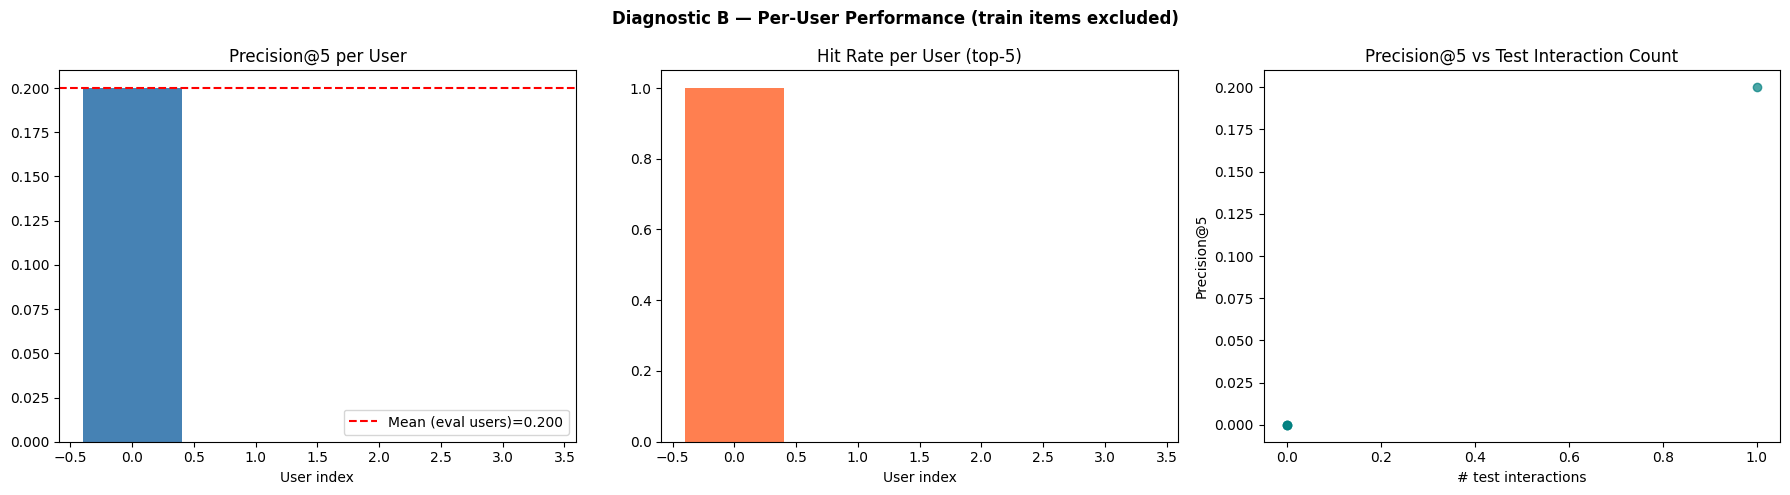

Users with test data: 1 / 4
       precision_at_5  hit_rate  true_positives  false_positives  \
count             1.0       1.0             1.0              1.0   
mean              0.2       1.0             1.0              3.0   
std               NaN       NaN             NaN              NaN   
min               0.2       1.0             1.0              3.0   
25%               0.2       1.0             1.0              3.0   
50%               0.2       1.0             1.0              3.0   
75%               0.2       1.0             1.0              3.0   
max               0.2       1.0             1.0              3.0   

       n_recommendations_considered  
count                           1.0  
mean                            4.0  
std                             NaN  
min                             4.0  
25%                             4.0  
50%                             4.0  
75%                             4.0  
max                             4.0  


In [57]:
# Diagnostic B: Per-user Precision@5, hit rate, and ranking outcome counts
from lightfm.evaluation import precision_at_k as pak
from scipy.sparse import csr_matrix as to_csr

# P@5 with train items excluded (consistent with final eval)
per_user_p5 = pak(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5,
    preserve_rows=True,
    num_threads=4,
)

test_csr = to_csr(test_interactions)
train_csr_diag = to_csr(train_interactions)
n_users_diag = test_csr.shape[0]
n_items_diag = test_csr.shape[1]

hit_rates = []
tp_list, fp_list, fn_list, reco_count_list = [], [], [], []

for uid in range(n_users_diag):
    true_items = set(test_csr.getrow(uid).indices)
    if not true_items:
        hit_rates.append(np.nan)
        tp_list.append(0)
        fp_list.append(0)
        fn_list.append(0)
        reco_count_list.append(0)
        continue

    scores = model.predict(
        user_ids=np.repeat(uid, n_items_diag),
        item_ids=np.arange(n_items_diag),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )

    known_train_items = set(train_csr_diag.getrow(uid).indices)
    if known_train_items:
        scores[list(known_train_items)] = -np.inf

    candidate_ids = np.flatnonzero(np.isfinite(scores))
    top_k = min(5, len(candidate_ids))
    top_items = set(candidate_ids[np.argsort(scores[candidate_ids])[-top_k:]].tolist()) if top_k > 0 else set()
    hits = top_items & true_items

    tp_list.append(len(hits))
    fp_list.append(max(top_k - len(hits), 0))
    fn_list.append(max(len(true_items) - len(hits), 0))
    reco_count_list.append(top_k)
    hit_rates.append(1 if len(hits) > 0 else 0)

user_diag_df = pd.DataFrame({
    'user_idx': np.arange(n_users_diag),
    'precision_at_5': np.asarray(per_user_p5).reshape(-1),
    'hit_rate': np.asarray(hit_rates, dtype=float),
    'n_test_interactions': [test_csr.getrow(u).nnz for u in range(n_users_diag)],
    'n_recommendations_considered': reco_count_list,
    'true_positives': tp_list,
    'false_positives': fp_list,
    'false_negatives': fn_list,
})

eval_users_b = user_diag_df[user_diag_df['n_test_interactions'] > 0]

fig_b, axes_b = plt.subplots(1, 3, figsize=(18, 5))
fig_b.suptitle('Diagnostic B — Per-User Performance (train items excluded)', fontweight='bold')

axes_b[0].bar(range(n_users_diag), user_diag_df['precision_at_5'], color='steelblue')
axes_b[0].axhline(np.nanmean(eval_users_b['precision_at_5']), color='red', linestyle='--',
                   label=f"Mean (eval users)={np.nanmean(eval_users_b['precision_at_5']):.3f}")
axes_b[0].set_title('Precision@5 per User')
axes_b[0].set_xlabel('User index')
axes_b[0].legend()

axes_b[1].bar(range(n_users_diag), user_diag_df['hit_rate'].fillna(0), color='coral')
axes_b[1].set_title('Hit Rate per User (top-5)')
axes_b[1].set_xlabel('User index')

axes_b[2].scatter(user_diag_df['n_test_interactions'], user_diag_df['precision_at_5'], alpha=0.7, color='teal')
axes_b[2].set_title('Precision@5 vs Test Interaction Count')
axes_b[2].set_xlabel('# test interactions')
axes_b[2].set_ylabel('Precision@5')

plt.tight_layout()
plt.show()

print(f'Users with test data: {len(eval_users_b)} / {n_users_diag}')
print(eval_users_b[['precision_at_5', 'hit_rate', 'true_positives', 'false_positives', 'n_recommendations_considered']].describe().round(3))

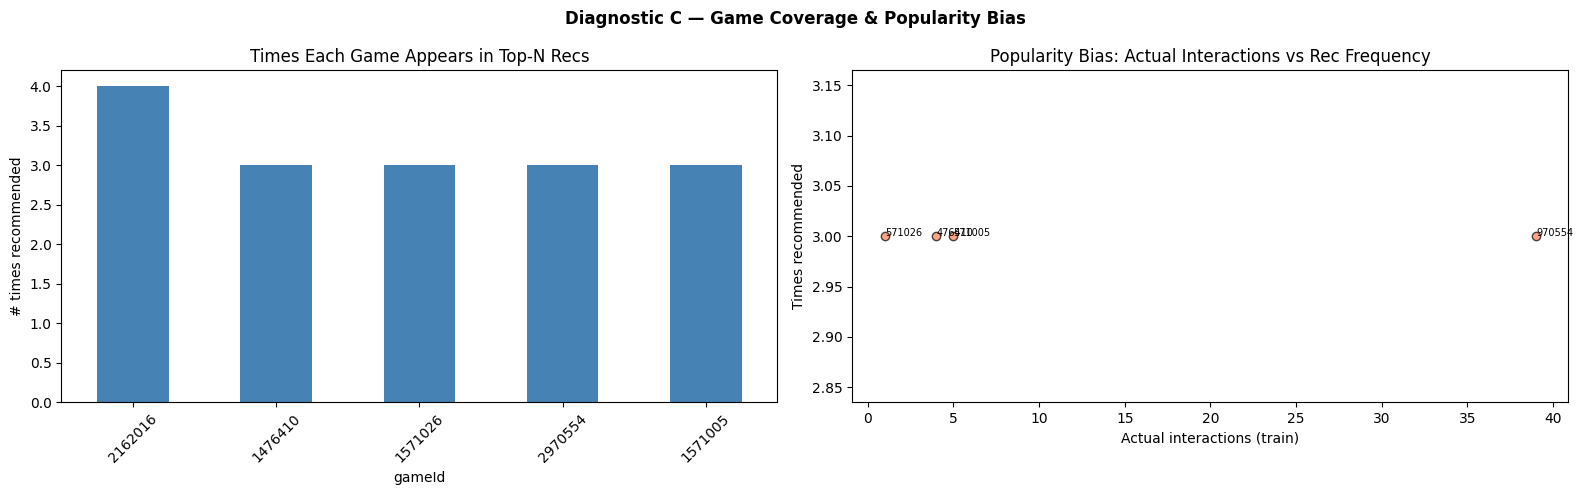

Games recommended at least once: 5 / 5
Coverage: 100.0%


In [58]:
# C: How often each game appears in top-5 recommendations across all users
from collections import Counter

all_recs = []
train_csr = to_csr(train_interactions)
n_items = train_csr.shape[1]

for uid in range(train_csr.shape[0]):
    scores = model.predict(
        user_ids=np.repeat(uid, n_items),
        item_ids=np.arange(n_items),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )
    known = set(train_csr.getrow(uid).indices)
    if known:
        scores[list(known)] = -np.inf

    candidate_ids = np.flatnonzero(np.isfinite(scores))
    if len(candidate_ids) == 0:
        continue

    top_k = min(5, len(candidate_ids))
    top5 = candidate_ids[np.argsort(scores[candidate_ids])[-top_k:]]
    all_recs.extend([idx_to_item[i] for i in top5])

rec_counts = pd.Series(Counter(all_recs)).sort_values(ascending=False) if len(all_recs) > 0 else pd.Series(dtype='int64')
actual_counts = train_events_df['gameId'].value_counts() if 'train_events_df' in globals() else events_df['gameId'].value_counts()

fig_c, axes_c = plt.subplots(1, 2, figsize=(16, 5))
fig_c.suptitle('Diagnostic C — Game Coverage & Popularity Bias', fontweight='bold')

if len(rec_counts) > 0:
    rec_counts.plot(kind='bar', ax=axes_c[0], color='steelblue')
else:
    axes_c[0].text(0.5, 0.5, 'No recommendable items left', ha='center', va='center')
axes_c[0].set_title('Times Each Game Appears in Top-N Recs')
axes_c[0].set_xlabel('gameId')
axes_c[0].set_ylabel('# times recommended')
axes_c[0].tick_params(axis='x', rotation=45)

common_games = rec_counts.index.intersection(actual_counts.index) if len(rec_counts) > 0 else []
if len(common_games) > 0:
    axes_c[1].scatter(
        actual_counts[common_games].values,
        rec_counts[common_games].values,
        alpha=0.7, color='coral', edgecolors='black'
    )
    for g in common_games:
        axes_c[1].annotate(str(g)[-6:], (actual_counts[g], rec_counts[g]), fontsize=7)
else:
    axes_c[1].text(0.5, 0.5, 'No overlap between recs and actuals', ha='center', va='center')
axes_c[1].set_title('Popularity Bias: Actual Interactions vs Rec Frequency')
axes_c[1].set_xlabel('Actual interactions (train)')
axes_c[1].set_ylabel('Times recommended')

plt.tight_layout()
plt.show()

print(f'Games recommended at least once: {len(rec_counts)} / {n_items}')
print(f'Coverage: {len(rec_counts)/n_items*100:.1f}%') if n_items else print('Coverage: N/A')

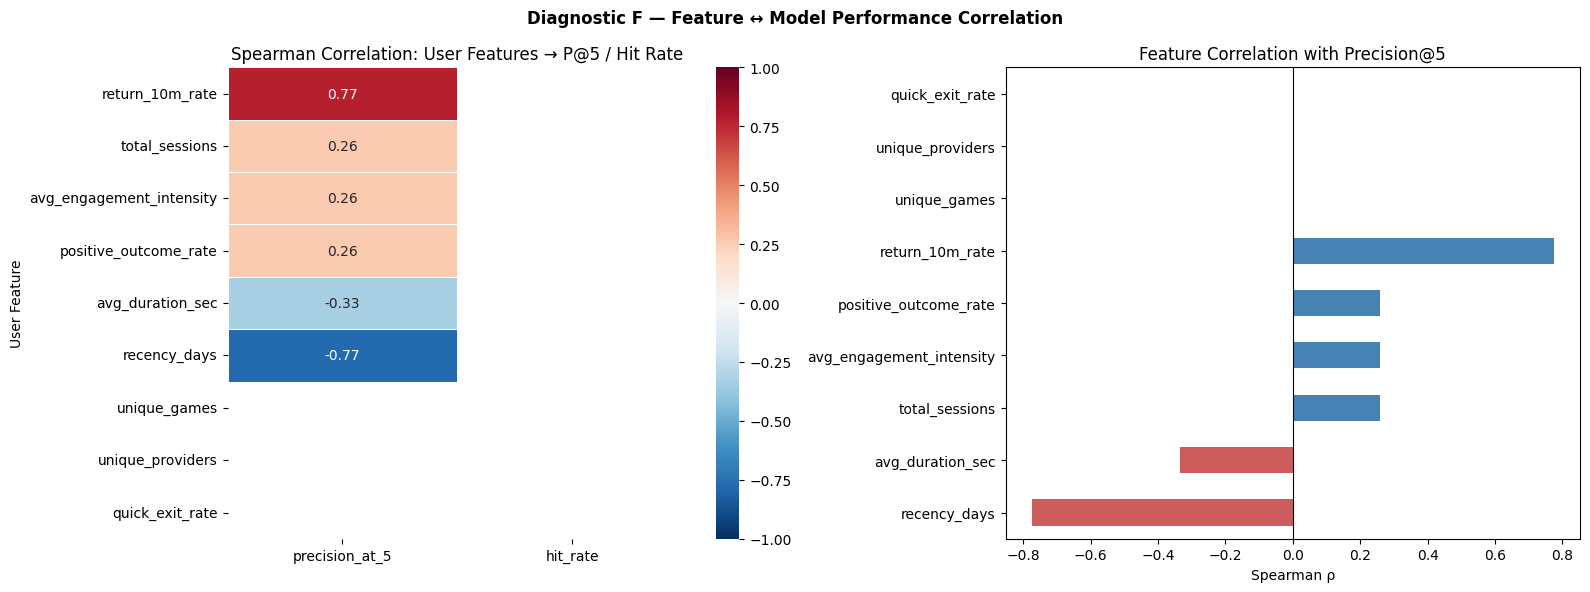


Key correlations with Precision@5:
  return_10m_rate                ρ = +0.775 ↑
  total_sessions                 ρ = +0.258 ↑
  avg_engagement_intensity       ρ = +0.258 ↑
  positive_outcome_rate          ρ = +0.258 ↑
  avg_duration_sec               ρ = -0.333 ↓
  recency_days                   ρ = -0.775 ↓
  unique_games                   ρ = +nan ↓
  unique_providers               ρ = +nan ↓
  quick_exit_rate                ρ = +nan ↓


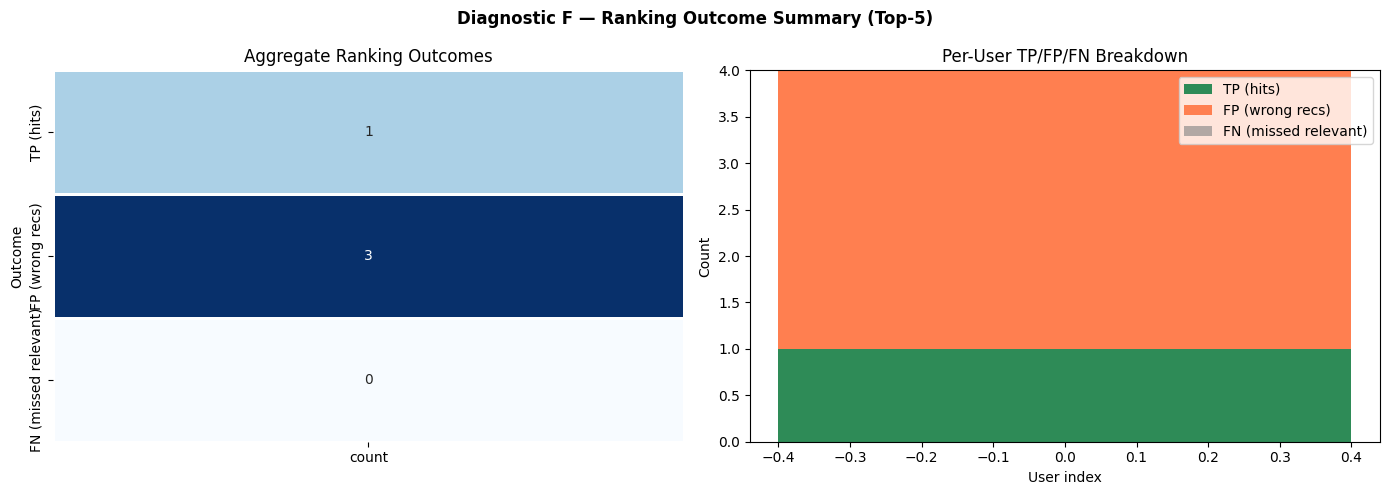


=== Ranking Outcome Summary (Top-5) ===
Total TP (hits):         1
Total FP (wrong recs):   3
Total FN (missed items): 0
Aggregate Precision@5:   0.2500
Aggregate Recall@5:      1.0000
Aggregate F1@5:          0.4000
Users evaluated:         1


In [59]:
# Diagnostic F: Feature ↔ Performance Correlation + Ranking Outcome Summary

# --- 1. Feature-Performance Correlation ---
idx_to_user = {v: k for k, v in user_id_map.items()}
user_diag_df['userId'] = user_diag_df['user_idx'].map(idx_to_user)

corr_feature_source = train_user_features_df if 'train_user_features_df' in globals() else user_features_df
corr_df = user_diag_df.merge(corr_feature_source, on='userId', how='left')

feature_cols = [
    'total_sessions', 'unique_games', 'unique_providers',
    'avg_duration_sec', 'quick_exit_rate', 'return_10m_rate',
    'positive_outcome_rate', 'avg_engagement_intensity', 'recency_days',
]
feature_cols = [c for c in feature_cols if c in corr_df.columns and pd.api.types.is_numeric_dtype(corr_df[c])]

target_cols = ['precision_at_5', 'hit_rate']

if len(feature_cols) > 0:
    corr_matrix = corr_df[feature_cols + target_cols].corr(method='spearman')
    corr_with_perf = corr_matrix.loc[feature_cols, target_cols].sort_values('precision_at_5', ascending=False)

    fig_f1, axes_f1 = plt.subplots(1, 2, figsize=(16, 6))
    fig_f1.suptitle('Diagnostic F — Feature ↔ Model Performance Correlation', fontweight='bold')

    sns.heatmap(
        corr_with_perf, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, ax=axes_f1[0], linewidths=0.5,
    )
    axes_f1[0].set_title('Spearman Correlation: User Features → P@5 / Hit Rate')
    axes_f1[0].set_ylabel('User Feature')

    corr_with_perf['precision_at_5'].sort_values().plot(
        kind='barh', ax=axes_f1[1],
        color=corr_with_perf['precision_at_5'].sort_values().apply(
            lambda x: 'steelblue' if x >= 0 else 'indianred'
        ),
    )
    axes_f1[1].set_title('Feature Correlation with Precision@5')
    axes_f1[1].set_xlabel('Spearman ρ')
    axes_f1[1].axvline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()

    print('\nKey correlations with Precision@5:')
    for feat, val in corr_with_perf['precision_at_5'].items():
        sign = '↑' if val > 0 else '↓'
        print(f'  {feat:<30s} ρ = {val:+.3f} {sign}')
else:
    print('No numeric user features available for correlation analysis.')

# --- 2. Ranking outcome summary (Top-5) ---
eval_users = user_diag_df[user_diag_df['n_test_interactions'] > 0]
total_tp = int(eval_users['true_positives'].sum())
total_fp = int(eval_users['false_positives'].sum())
total_fn = int(eval_users['false_negatives'].sum())

outcome_summary = pd.DataFrame({
    'count': [total_tp, total_fp, total_fn]
}, index=['TP (hits)', 'FP (wrong recs)', 'FN (missed relevant)'])

fig_f2, axes_f2 = plt.subplots(1, 2, figsize=(14, 5))
fig_f2.suptitle('Diagnostic F — Ranking Outcome Summary (Top-5)', fontweight='bold')

sns.heatmap(
    outcome_summary,
    annot=True, fmt='d', cmap='Blues',
    cbar=False, ax=axes_f2[0], linewidths=1,
 )
axes_f2[0].set_title('Aggregate Ranking Outcomes')
axes_f2[0].set_ylabel('Outcome')

eval_users_plot = eval_users.head(20)
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['true_positives'].values, label='TP (hits)', color='seagreen')
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['false_positives'].values,
            bottom=eval_users_plot['true_positives'].values, label='FP (wrong recs)', color='coral')
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['false_negatives'].values,
            bottom=(eval_users_plot['true_positives'] + eval_users_plot['false_positives']).values,
            label='FN (missed relevant)', color='gray', alpha=0.6)
axes_f2[1].set_title('Per-User TP/FP/FN Breakdown')
axes_f2[1].set_xlabel('User index')
axes_f2[1].set_ylabel('Count')
axes_f2[1].legend()

plt.tight_layout()
plt.show()

precision_agg = total_tp / max(total_tp + total_fp, 1)
recall_agg = total_tp / max(total_tp + total_fn, 1)
f1_agg = 2 * precision_agg * recall_agg / max(precision_agg + recall_agg, 1e-9)

print(f'\n=== Ranking Outcome Summary (Top-5) ===')
print(f'Total TP (hits):         {total_tp}')
print(f'Total FP (wrong recs):   {total_fp}')
print(f'Total FN (missed items): {total_fn}')
print(f'Aggregate Precision@5:   {precision_agg:.4f}')
print(f'Aggregate Recall@5:      {recall_agg:.4f}')
print(f'Aggregate F1@5:          {f1_agg:.4f}')
print(f'Users evaluated:         {len(eval_users)}')

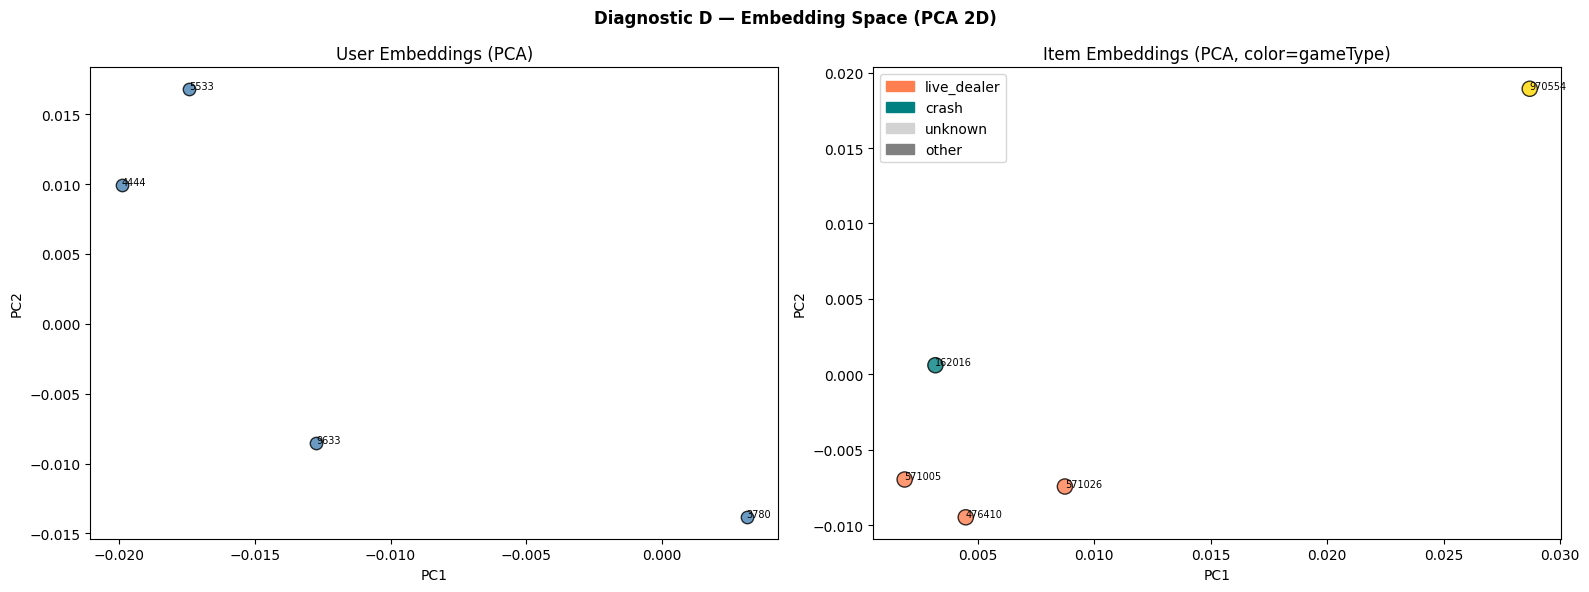

PCA explained variance: PC1=0.333, PC2=0.221


In [36]:
# Diagnostic D: Visualize user and item embeddings in 2D via PCA
from sklearn.decomposition import PCA

user_biases, user_embeddings = model.get_user_representations(features=user_features_matrix)
item_biases, item_embeddings = model.get_item_representations(features=item_features_matrix)

pca = PCA(n_components=2, random_state=42)
all_embeddings = np.vstack([user_embeddings, item_embeddings])
all_2d = pca.fit_transform(all_embeddings)

n_u = user_embeddings.shape[0]
user_2d = all_2d[:n_u]
item_2d = all_2d[n_u:]

fig_d, axes_d = plt.subplots(1, 2, figsize=(16, 6))
fig_d.suptitle('Diagnostic D — Embedding Space (PCA 2D)', fontweight='bold')

# Users
axes_d[0].scatter(user_2d[:, 0], user_2d[:, 1], color='steelblue', s=80, alpha=0.8, edgecolors='black')
for i, uid in enumerate(active_users):
    axes_d[0].annotate(str(uid)[-4:], user_2d[i], fontsize=7)
axes_d[0].set_title('User Embeddings (PCA)')
axes_d[0].set_xlabel('PC1'); axes_d[0].set_ylabel('PC2')

# Items — color by game type if available
game_type_map = events_df.drop_duplicates('gameId').set_index('gameId')['gameType'].to_dict()
item_colors = [{'live_dealer': 'coral', 'crash': 'teal', 'slot': 'gold', 'unknown': 'lightgray'}.get(
    game_type_map.get(gid, 'unknown'), 'gray') for gid in active_items]

axes_d[1].scatter(item_2d[:, 0], item_2d[:, 1], c=item_colors, s=120, alpha=0.8, edgecolors='black')
for i, gid in enumerate(active_items):
    axes_d[1].annotate(str(gid)[-6:], item_2d[i], fontsize=7)
axes_d[1].set_title('Item Embeddings (PCA, color=gameType)')
axes_d[1].set_xlabel('PC1'); axes_d[1].set_ylabel('PC2')

from matplotlib.patches import Patch
legend = [Patch(color='coral', label='live_dealer'),
          Patch(color='teal', label='crash'),
          Patch(color='lightgray', label='unknown'),
          Patch(color='gray', label='other')]
axes_d[1].legend(handles=legend)

plt.tight_layout()
plt.show()

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')

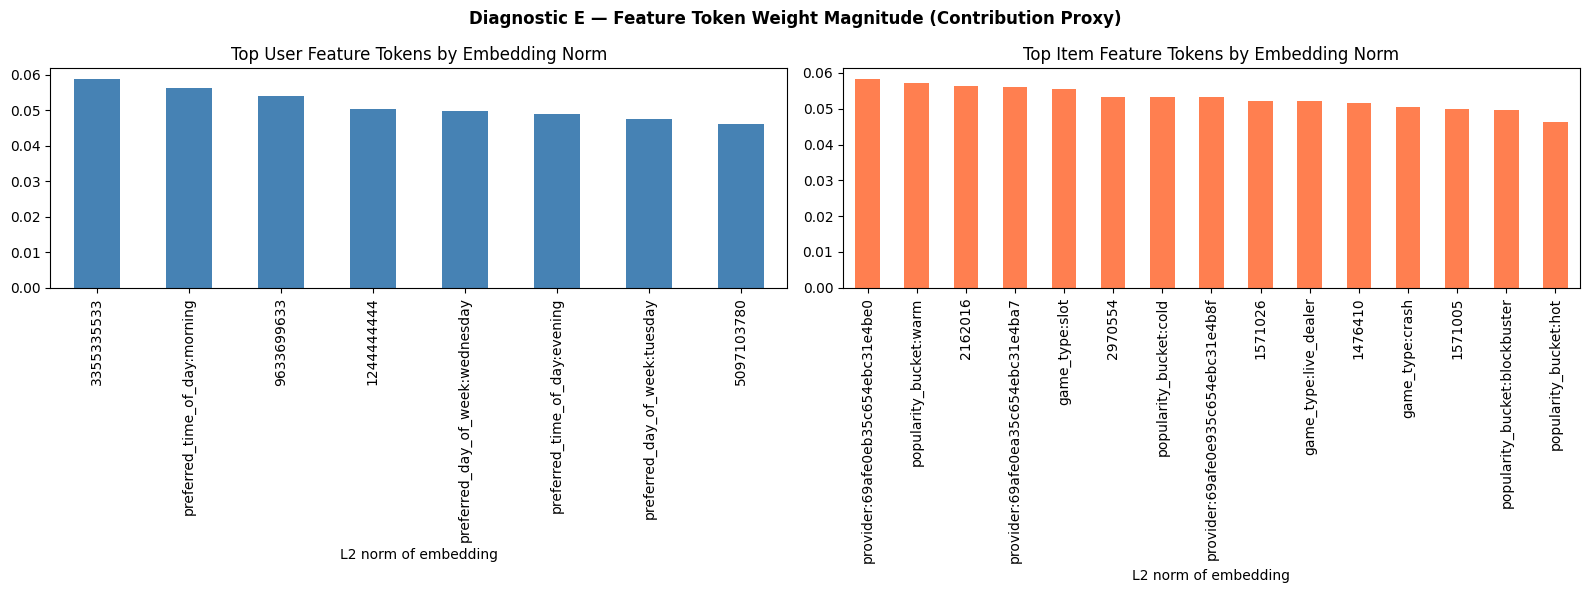

Top user tokens: {'3355335533': 0.05883905291557312, 'preferred_time_of_day:morning': 0.05622079223394394, '9633699633': 0.05406590923666954, '1244444444': 0.050424572080373764, 'preferred_day_of_week:wednesday': 0.04985278844833374}
Top item tokens: {'provider:69afe0eb35c654ebc31e4be0': 0.058368176221847534, 'popularity_bucket:warm': 0.05728815123438835, '2162016': 0.056425273418426514, 'provider:69afe0ea35c654ebc31e4ba7': 0.05610639229416847, 'game_type:slot': 0.05540137365460396}


In [37]:
# E: Which user/item feature tokens have highest weight magnitude in embeddings
# Proxy for feature importance in LightFM

user_feat_map = dataset.mapping()[1]  # token -> col index
item_feat_map = dataset.mapping()[3]

_, user_feat_embeddings = model.get_user_representations(features=user_features_matrix)
_, item_feat_raw = model.get_item_representations(features=item_features_matrix)

# User feature token norms (contribution proxy)
user_feat_matrix_raw = dataset.build_user_features(
    (str(r['userId']), user_tokens(r)) for _, r in ufe.iterrows()
)
user_token_norms = {}
for token, idx in user_feat_map.items():
    col = user_feat_matrix_raw.getcol(idx)
    if col.nnz > 0:
        # Get embedding row for this feature index and compute norm
        emb = model.user_embeddings[idx] if idx < model.user_embeddings.shape[0] else None
        if emb is not None:
            user_token_norms[token] = float(np.linalg.norm(emb))

item_token_norms = {}
for token, idx in item_feat_map.items():
    emb = model.item_embeddings[idx] if idx < model.item_embeddings.shape[0] else None
    if emb is not None:
        item_token_norms[token] = float(np.linalg.norm(emb))

user_contrib = pd.Series(user_token_norms).sort_values(ascending=False)
item_contrib = pd.Series(item_token_norms).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Diagnostic E — Feature Token Weight Magnitude (Contribution Proxy)', fontweight='bold')

user_contrib.head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top User Feature Tokens by Embedding Norm')
axes[0].set_xlabel('L2 norm of embedding')

item_contrib.head(15).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top Item Feature Tokens by Embedding Norm')
axes[1].set_xlabel('L2 norm of embedding')

plt.tight_layout()
plt.show()

print('Top user tokens:', user_contrib.head(5).to_dict())
print('Top item tokens:', item_contrib.head(5).to_dict())

## Model Audit

- Better session modeling when robust `sessionId`, `roundsPlayed`, and true session boundaries are fully available.
- Device and entry point enrichment from clickstream/app telemetry instead of defaults.
- Temporal sequence modeling (next-game prediction using session order, not only aggregates).
- Real-time features (recent streaks, live context) for online serving.
- Cold-start handling via metadata embeddings and business-rule fallback.
- Contextual bandits / re-ranking for exploration vs exploitation balance.
- Stronger provider/gameType normalization dictionary managed centrally.

> These are intentionally **not implemented** in this notebook yet.

In [60]:
# Final pipeline readiness report

print('=' * 70)
print('REAL-DATA RECSYS PIPELINE — READINESS REPORT')
print('=' * 70)

print('\n[1] TDD schema validation')
missing_cols = [c for c in SCHEMA_COLUMNS if c not in events_df.columns]
print('Missing schema columns:', missing_cols if missing_cols else 'None ✅')

print('\n[2] Enum coverage checks')
game_types_present = sorted(events_df['gameType'].dropna().unique().tolist())
providers_present = sorted(events_df['provider'].dropna().unique().tolist())
device_types_present = sorted(events_df['deviceType'].dropna().unique().tolist())
entry_points_present = sorted(events_df['entryPoint'].dropna().unique().tolist())
print('gameType values:', game_types_present)
print('provider values:', providers_present)
print('deviceType values:', device_types_present)
print('entryPoint values:', entry_points_present)

invalid_game_types = sorted(set(game_types_present) - set(VALID_GAME_TYPES))
invalid_providers = sorted(set(providers_present) - set(VALID_PROVIDERS))
invalid_device_types = sorted(set(device_types_present) - set(VALID_DEVICE_TYPES))
# entryPoint is intentionally semi-open to retain real source labels
non_standard_entry_points = sorted(set(entry_points_present) - set(VALID_ENTRY_POINTS))
print('Invalid gameType values:', invalid_game_types if invalid_game_types else 'None ✅')
print('Invalid provider values:', invalid_providers if invalid_providers else 'None ✅')
print('Invalid deviceType values:', invalid_device_types if invalid_device_types else 'None ✅')
print('Additional entryPoint values retained from source:', non_standard_entry_points if non_standard_entry_points else 'None')

print('\n[3] Output datasets')
print(f'events_df:       {events_df.shape}')
print(f'user_features_df:{user_features_df.shape}')
print(f'game_features_df:{game_features_df.shape}')
print(f'user_game_df:    {user_game_df.shape}')
print(f'model_ready_df:  {model_ready_df.shape}')

print('\n[4] Context field coverage')
device_unknown_rate = (events_df['deviceType'].eq('unknown').mean() * 100) if len(events_df) else 0
entry_unknown_rate = (events_df['entryPoint'].eq('unknown').mean() * 100) if len(events_df) else 0
print(f'deviceType unknown rate: {device_unknown_rate:.2f}%')
print(f'entryPoint unknown rate: {entry_unknown_rate:.2f}%')

if 'deviceType_raw' in transactions_df.columns:
    print('\nTop deviceType raw -> mapped pairs:')
    sample_map = pd.DataFrame({
        'raw': transactions_df['deviceType_raw'].astype(str).fillna('nan'),
        'mapped': transactions_df['deviceType_raw'].astype(str).map(map_device_type)
    })
    print(sample_map.value_counts().head(8))

if 'entryPoint_raw' in transactions_df.columns:
    print('\nTop entryPoint raw -> mapped pairs:')
    sample_map = pd.DataFrame({
        'raw': transactions_df['entryPoint_raw'].astype(str).fillna('nan'),
        'mapped': transactions_df['entryPoint_raw'].astype(str).map(map_entry_point)
    })
    print(sample_map.value_counts().head(12))

print('\nPipeline is schema-aligned and ready for downstream model training steps.')
print('=' * 70)

REAL-DATA RECSYS PIPELINE — READINESS REPORT

[1] TDD schema validation
Missing schema columns: None ✅

[2] Enum coverage checks
gameType values: ['crash', 'live_dealer', 'slot']
provider values: ['unknown']
deviceType values: ['desktop']
entryPoint values: ['livecasino', 'unknown']
Invalid gameType values: None ✅
Invalid provider values: None ✅
Invalid deviceType values: None ✅
Additional entryPoint values retained from source: None

[3] Output datasets
events_df:       (57, 17)
user_features_df:(4, 17)
game_features_df:(5, 11)
user_game_df:    (5, 13)
model_ready_df:  (5, 38)

[4] Context field coverage
deviceType unknown rate: 0.00%
entryPoint unknown rate: 38.60%

Top deviceType raw -> mapped pairs:
raw      mapped 
desktop  desktop    57
Name: count, dtype: int64

Top entryPoint raw -> mapped pairs:
raw         mapped    
livecasino  livecasino    35
nan         unknown       22
Name: count, dtype: int64

Pipeline is schema-aligned and ready for downstream model training steps.


In [61]:
# Context fields validation after real-source integration
print(events_df['deviceType'].value_counts(dropna=False))
print(events_df['entryPoint'].value_counts(dropna=False))

# implicit_score range check (if available)
if 'user_game_df' in globals() and 'implicit_score' in user_game_df.columns:
    print(user_game_df['implicit_score'].describe())
else:
    print('user_game_df not built yet in current run; skip implicit_score check.')

deviceType
desktop    57
Name: count, dtype: int64
entryPoint
livecasino    35
unknown       22
Name: count, dtype: int64
count    5.000000
mean     0.518240
std      0.195074
min      0.380300
25%      0.422300
50%      0.454200
75%      0.472900
max      0.861500
Name: implicit_score, dtype: float64


In [62]:
# --- Final requested summary (matched to this notebook's variable names) ---

import pandas as pd
from IPython.display import display

total_tx = len(transactions_df) if 'transactions_df' in globals() else 0
session_matched = int(transactions_df['session_duration_sec'].notna().sum()) if ('transactions_df' in globals() and 'session_duration_sec' in transactions_df.columns) else 0
entry_matched = int(transactions_df['entryPoint_raw'].notna().sum()) if ('transactions_df' in globals() and 'entryPoint_raw' in transactions_df.columns) else 0
device_matched = int(transactions_df['deviceType_raw'].notna().sum()) if ('transactions_df' in globals() and 'deviceType_raw' in transactions_df.columns) else 0

session_cov_pct = (session_matched / total_tx * 100.0) if total_tx else 0.0
entry_cov_pct = (entry_matched / total_tx * 100.0) if total_tx else 0.0
device_cov_pct = (device_matched / total_tx * 100.0) if total_tx else 0.0

print("\n==============================")
print("Session enrichment coverage")
print("==============================")
print(f"Session duration coverage: {session_cov_pct:.1f}%")

print("\nTransactions with session duration")
print(f"{session_matched}/{total_tx}")

print("\nentryPoint coverage")
print(f"{entry_cov_pct:.1f}% ({entry_matched}/{total_tx})")

print("\nDevice enrichment coverage")
print(f"{device_cov_pct:.1f}% ({device_matched}/{total_tx})")

print("\ndeviceType_raw coverage")
print(f"{device_cov_pct:.1f}%")

print("\n==============================")
print("LightFM artifacts")
print("==============================")
print("\ninteractions/train/test shapes")
print({
    "interactions": interactions.shape if 'interactions' in globals() else None,
    "train": train_interactions.shape if 'train_interactions' in globals() else None,
    "test": test_interactions.shape if 'test_interactions' in globals() else None,
})

print("\nuser/item feature matrix shapes")
print({
    "user_features_matrix": user_features_matrix.shape if 'user_features_matrix' in globals() else None,
    "item_features_matrix": item_features_matrix.shape if 'item_features_matrix' in globals() else None,
})

print("\ntoken lists")
print({
    "user_feature_vocab": user_feature_vocab if 'user_feature_vocab' in globals() else None,
    "item_feature_vocab": item_feature_vocab if 'item_feature_vocab' in globals() else None,
})

print("\n==============================")
print("Final evaluation")
print("==============================")
print("\nTrain/Test Precision@5")
print({
    "train_precision_at_5": float(final_train_p5) if 'final_train_p5' in globals() else None,
    "test_precision_at_5": float(final_test_p5) if 'final_test_p5' in globals() else None,
})

print("\nTrain/Test AUC")
print({
    "train_auc": float(final_train_auc) if 'final_train_auc' in globals() else None,
    "test_auc": float(final_test_auc) if 'final_test_auc' in globals() else None,
})

print("\nNDCG@5")
print(float(final_ndcg5) if 'final_ndcg5' in globals() else None)

print("\n==============================")
print("Diagnostic B summary")
print("==============================")
diagnostic_b_summary = None
if 'eval_users_b' in globals() and len(eval_users_b) > 0:
    diagnostic_b_summary = eval_users_b[['precision_at_5', 'hit_rate', 'true_positives', 'false_positives']].describe().round(3)
elif 'user_diag_df' in globals() and len(user_diag_df) > 0:
    diagnostic_b_summary = user_diag_df[['precision_at_5', 'hit_rate', 'true_positives', 'false_positives']].describe().round(3)

if diagnostic_b_summary is not None:
    display(diagnostic_b_summary)
else:
    print("N/A")

print("\n==============================")
print("the final .describe() table")
print("==============================")
if diagnostic_b_summary is not None:
    display(diagnostic_b_summary)
elif 'model_ready_df' in globals() and hasattr(model_ready_df, 'describe'):
    display(model_ready_df.describe(include='all'))
else:
    print("N/A")


Session enrichment coverage
Session duration coverage: 61.4%

Transactions with session duration
35/57

entryPoint coverage
61.4% (35/57)

Device enrichment coverage
100.0% (57/57)

deviceType_raw coverage
100.0%

LightFM artifacts

interactions/train/test shapes
{'interactions': (4, 5), 'train': (4, 5), 'test': (4, 5)}

user/item feature matrix shapes
{'user_features_matrix': (4, 11), 'item_features_matrix': (5, 13)}

token lists
{'user_feature_vocab': ['preferred_day_of_week:tuesday', 'preferred_day_of_week:wednesday', 'preferred_device:desktop', 'preferred_entry_point:livecasino', 'preferred_entry_point:unknown', 'preferred_time_of_day:evening', 'preferred_time_of_day:morning'], 'item_feature_vocab': ['game_type:crash', 'game_type:live_dealer', 'game_type:slot', 'popularity_bucket:blockbuster', 'popularity_bucket:cold', 'popularity_bucket:hot', 'popularity_bucket:warm', 'provider:unknown']}

Final evaluation

Train/Test Precision@5
{'train_precision_at_5': 0.20000000298023224, 'tes

,precision_at_5,hit_rate,true_positives,false_positives
count,1.0,1.0,1.0,1.0
mean,0.2,1.0,1.0,3.0
std,NaN,NaN,NaN,NaN
min,0.2,1.0,1.0,3.0
25%,0.2,1.0,1.0,3.0
50%,0.2,1.0,1.0,3.0
75%,0.2,1.0,1.0,3.0
max,0.2,1.0,1.0,3.0



the final .describe() table


,precision_at_5,hit_rate,true_positives,false_positives
count,1.0,1.0,1.0,1.0
mean,0.2,1.0,1.0,3.0
std,NaN,NaN,NaN,NaN
min,0.2,1.0,1.0,3.0
25%,0.2,1.0,1.0,3.0
50%,0.2,1.0,1.0,3.0
75%,0.2,1.0,1.0,3.0
max,0.2,1.0,1.0,3.0
